# Topic: Predicting the severity of accidents based on traffic conditions

## Packages

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal, chi2
import requests
from datetime import datetime

# Statsmodels
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve
)
from sklearn.utils import resample

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [32]:
pd.set_option('display.max_columns', None)

## Raw Data import and combine (Fixed: Holiday Problem)

In [33]:
df_accident = pd.read_excel('24pubdb.xls', sheet_name='accident2024')  # Accident dataset
df_extra = pd.read_excel('Attachment2024.xls', sheet_name='accident2024')   # Extra information
df = pd.merge(df_accident, df_extra, on="Serial", how="left")

# Rename columns
df = df.rename(columns={
    "Serial": "serial",
    "Severity": "severity",
    "District Council District_x": "district",
    "Hit and Run": "hit_and_run",
    "Weather": "weather",
    "Rain": "rain",
    "Natural Light": "natural_light",
    "Junction Control": "junction_control",
    "Road Classification": "road_classification",
    "Vehicle Movements": "vehicle_movements",
    "Type of Collision": "type_of_collision",
    "No. of Vehicles Involved": "num_vehicles_involved",
    "No. of Casualties": "num_casualties",
    "Date": "date",
    "Time": "time",
    "Coordinates of accident (easting grid)": "accident_easting",
    "Coordinates of accident (northing grid)": "accident_northing",
    "Street Name": "street_name"
})

# Drop the duplicate column
df = df.drop(columns=["District Council District_y"])

# Convert date and time into datetime
df["date"] = pd.to_datetime(df["date"])
df["datetime"] = df["date"] + pd.to_timedelta(df["time"], unit="m")

# AM/PM column: 0 = AM, 1 = PM
df["am_pm"] = df["datetime"].dt.hour.apply(lambda h: 0 if h < 12 else 1)

# Time slot column: ordered categories
def assign_time_slot(hour):
    if 0 <= hour < 6:
        return 0  # Late Night
    elif 6 <= hour < 12:
        return 1  # Morning
    elif 12 <= hour < 18:
        return 2  # Afternoon
    else:
        return 3  # Evening

df["time_slot"] = df["datetime"].dt.hour.apply(assign_time_slot)

# Holiday column: 0 = Not Holiday, 1 = Holiday (include Sunday)
# Fetch JSON from 1823.gov.hk
url = "https://www.1823.gov.hk/common/ical/tc.json"
data = requests.get(url).json()
# Extract events
events = data["vcalendar"][0]["vevent"]

# Convert to list of dicts
holiday_list = []
for e in events:
    date_str = e["dtstart"][0]
    date = datetime.strptime(date_str, "%Y%m%d").date()
    name = e["summary"]
    holiday_list.append({"date": date, "holiday": name})

# Create DataFrame
df_holiday = pd.DataFrame(holiday_list)
df_holiday['date'] = pd.to_datetime(df_holiday['date'])
holiday_dates = set(df_holiday['date'])
# Flag holidays OR Sundays (weekday: Sunday=6)
df['is_holiday'] = (df['date'].isin(holiday_dates) | (df['date'].dt.weekday == 6)).astype(int)


# Recode severity: merge Serious (2) into Fatal (1), keep Slight (3) as 0
df["severity"] = df["severity"].replace({2: 1, 3: 0})

df

,serial,severity,district,hit_and_run,weather,rain,natural_light,junction_control,road_classification,vehicle_movements,type_of_collision,num_vehicles_involved,num_casualties,date,time,accident_easting,accident_northing,street_name,datetime,am_pm,time_slot,is_holiday
0,1,0,WCH,2,1,1,3,6,2,1,1,1,3,2024-01-01,17,35547,14349,PEAK ROAD,2024-01-01 00:17:00,0,0,1
1,2,0,WCH,2,1,1,3,6,2,1,1,1,1,2024-01-01,30,36530,15531,HENNESSY ROAD,2024-01-01 00:30:00,0,0,1
2,3,0,WCH,2,1,1,3,6,2,1,4,1,1,2024-01-01,59,36415,15945,MARSH ROAD,2024-01-01 00:59:00,0,0,1
3,4,0,KT,2,1,1,3,6,2,5,2,3,2,2024-01-01,234,40999,19427,KWUN TONG ROAD,2024-01-01 03:54:00,0,0,1
4,5,0,SK,2,1,1,3,2,2,2,2,2,1,2024-01-01,244,47447,18350,CLEAR WATER BAY ROAD,2024-01-01 04:04:00,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18349,18350,0,KC,2,1,1,1,4,2,1,4,1,1,2024-12-24,1520,37255,19286,CHATHAM ROAD NORTH,2024-12-25 01:20:00,0,0,0
18350,18351,0,YTM,2,1,1,2,6,2,2,4,2,2,2024-10-05,205,not available,not available,CHATHAM ROAD SOUTH,2024-10-05 03:25:00,0,0,0
18351,18352,0,TM,2,1,1,1,6,2,1,3,1,1,2024-11-12,1900,not available,not available,TUEN MUN HEUNG SZE WUI ROAD,2024-11-13 07:40:00,0,1,0
18352,18353,0,YL,2,1,1,1,6,2,3,4,2,1,2024-11-02,1430,21257,35954,NAM SANG WAI ROAD,2024-11-02 23:50:00,1,3,0


## Exploratory Data Analysis

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18354 entries, 0 to 18353
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   serial                 18354 non-null  int64         
 1   severity               18354 non-null  int64         
 2   district               18354 non-null  object        
 3   hit_and_run            18354 non-null  int64         
 4   weather                18354 non-null  int64         
 5   rain                   18354 non-null  int64         
 6   natural_light          18354 non-null  int64         
 7   junction_control       18354 non-null  int64         
 8   road_classification    18354 non-null  int64         
 9   vehicle_movements      18354 non-null  int64         
 10  type_of_collision      18354 non-null  int64         
 11  num_vehicles_involved  18354 non-null  int64         
 12  num_casualties         18354 non-null  int64         
 13  d

In [35]:
categorical_cols = [
    "serial", "severity", "district", "hit_and_run", "weather", "rain",
    "natural_light", "junction_control", "road_classification",
    "vehicle_movements", "type_of_collision",
    "am_pm", "time_slot", "is_holiday"
]

# Convert to category dtype
df[categorical_cols] = df[categorical_cols].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18354 entries, 0 to 18353
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   serial                 18354 non-null  category      
 1   severity               18354 non-null  category      
 2   district               18354 non-null  category      
 3   hit_and_run            18354 non-null  category      
 4   weather                18354 non-null  category      
 5   rain                   18354 non-null  category      
 6   natural_light          18354 non-null  category      
 7   junction_control       18354 non-null  category      
 8   road_classification    18354 non-null  category      
 9   vehicle_movements      18354 non-null  category      
 10  type_of_collision      18354 non-null  category      
 11  num_vehicles_involved  18354 non-null  int64         
 12  num_casualties         18354 non-null  int64         
 13  d

In [36]:
# Display unique values for each categorical column
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: serial
[1, 2, 3, 4, 5, ..., 18350, 18351, 18352, 18353, 18354]
Length: 18354
Categories (18354, int64): [1, 2, 3, 4, ..., 18351, 18352, 18353, 18354]

Column: severity
[0, 1]
Categories (2, int64): [0, 1]

Column: district
['WCH', 'KT', 'SK', 'TM', 'KTS', ..., 'SSPO', 'ST', 'N', 'YL', 'TW']
Length: 18
Categories (18, object): ['CW', 'E', 'I', 'KC', ..., 'WCH', 'WTS', 'YL', 'YTM']

Column: hit_and_run
[2, 1]
Categories (2, int64): [1, 2]

Column: weather
[1, 2, 9, 3, 4]
Categories (5, int64): [1, 2, 3, 4, 9]

Column: rain
[1, 2, 9, 3]
Categories (4, int64): [1, 2, 3, 9]

Column: natural_light
[3, 2, 1, 9]
Categories (4, int64): [1, 2, 3, 9]

Column: junction_control
[6, 2, 1, 4, 3]
Categories (5, int64): [1, 2, 3, 4, 6]

Column: road_classification
[2, 1]
Categories (2, int64): [1, 2]

Column: vehicle_movements
[1, 5, 2, 4, 3, 6, 7]
Categories (7, int64): [1, 2, 3, 4, 5, 6, 7]

Column: type_of_collision
[1, 4, 2, 3]
Categories (4, int64): [1, 2, 3, 4]

Column: am_pm
[0, 1]
Cate

In [37]:
# Drop the columns (Retaining 'date' for weather imputation)
df = df.drop(columns=["num_casualties", "time", "accident_easting", "accident_northing", "street_name"])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18354 entries, 0 to 18353
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   serial                 18354 non-null  category      
 1   severity               18354 non-null  category      
 2   district               18354 non-null  category      
 3   hit_and_run            18354 non-null  category      
 4   weather                18354 non-null  category      
 5   rain                   18354 non-null  category      
 6   natural_light          18354 non-null  category      
 7   junction_control       18354 non-null  category      
 8   road_classification    18354 non-null  category      
 9   vehicle_movements      18354 non-null  category      
 10  type_of_collision      18354 non-null  category      
 11  num_vehicles_involved  18354 non-null  int64         
 12  date                   18354 non-null  datetime64[ns]
 13  d

## Data Cleansing

In [39]:
# Load vehicle data
df_vehicle = pd.read_excel('24pubdb.xls', sheet_name='vehicle2024')

# Driver Age and Vehicle Age
df_vehicle['driver_age'] = pd.to_numeric(df_vehicle['Driver Age'])
df_vehicle['year_of_manuf'] = pd.to_numeric(df_vehicle['Year of Manufacture'])
df_vehicle['veh_age'] = 2024 - df_vehicle['year_of_manuf']

# Remove duplicate columns
df_vehicle = df_vehicle.drop(columns=['Year of Manufacture', 'Driver Age'])
df_vehicle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31315 entries, 0 to 31314
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Serial                31315 non-null  int64  
 1   Driver Sex            31315 non-null  int64  
 2   Severity of Accident  31315 non-null  int64  
 3   Vehicle Class         31315 non-null  int64  
 4   driver_age            31315 non-null  int64  
 5   year_of_manuf         29023 non-null  float64
 6   veh_age               29023 non-null  float64
dtypes: float64(2), int64(5)
memory usage: 1.7 MB


In [40]:
# rename vehicle class in df_vehicle
veh_class_mapping = {
    1: 'motorcycle',
    2: 'private_car',
    3: 'public_light_bus',
    4: 'light_goods_vehicle',
    5: 'medium_goods_vehicle',
    6: 'heavy_goods_vehicle',
    7: 'francised_public_bus',
    8: 'non-franchised_public_bus',
    9: 'taxi',
    10: 'bicycle',
    11: 'tram',
    12: 'light_rail_vehicle',
    13: 'others'
}

# Apply the mapping to the 'Vehicle Class' column
df_vehicle['Vehicle Class'] = df_vehicle['Vehicle Class'].replace(veh_class_mapping)

In [41]:
df_vehicle.describe()

,Serial,Driver Sex,Severity of Accident,driver_age,year_of_manuf,veh_age
count,31315.000000,31315.000000,31315.000000,31315.000000,29023.000000,29023.000000
mean,9266.282325,1.244100,2.955421,68.003002,2015.989663,8.010337
std,5282.331563,1.130131,0.224182,142.037272,5.042794,5.042794
min,1.000000,1.000000,1.000000,2.000000,1959.000000,0.000000
25%,4734.500000,1.000000,3.000000,35.000000,2013.000000,4.000000
50%,9266.000000,1.000000,3.000000,46.000000,2016.000000,8.000000
75%,13857.000000,1.000000,3.000000,60.000000,2020.000000,11.000000
max,18354.000000,9.000000,3.000000,999.000000,2024.000000,65.000000


In [42]:
df_vehicle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31315 entries, 0 to 31314
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Serial                31315 non-null  int64  
 1   Driver Sex            31315 non-null  int64  
 2   Severity of Accident  31315 non-null  int64  
 3   Vehicle Class         31315 non-null  object 
 4   driver_age            31315 non-null  int64  
 5   year_of_manuf         29023 non-null  float64
 6   veh_age               29023 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 1.7+ MB


In [43]:
df_vehicle['Serial'].nunique()

18354

,count,mean,std,min,25%,50%,75%,max
Vehicle Class,,,,,,,,
bicycle,1891.0,38.468535,20.246874,2.0,19.00,37.0,56.0,95.0
francised_public_bus,1911.0,48.855573,11.507842,21.0,41.00,51.0,58.0,69.0
heavy_goods_vehicle,309.0,51.385113,12.714289,23.0,41.00,53.0,61.0,77.0
light_goods_vehicle,3429.0,44.963838,12.567896,18.0,35.00,43.0,54.0,80.0
light_rail_vehicle,3.0,42.000000,8.660254,37.0,37.00,37.0,44.5,52.0
medium_goods_vehicle,937.0,50.094984,11.655698,22.0,41.00,50.0,59.0,76.0
motorcycle,2825.0,38.877522,11.745707,18.0,30.00,37.0,47.0,87.0
non-franchised_public_bus,418.0,54.153110,11.846764,22.0,45.00,56.0,63.0,80.0
others,266.0,53.203008,13.462882,5.0,45.25,54.0,64.0,91.0


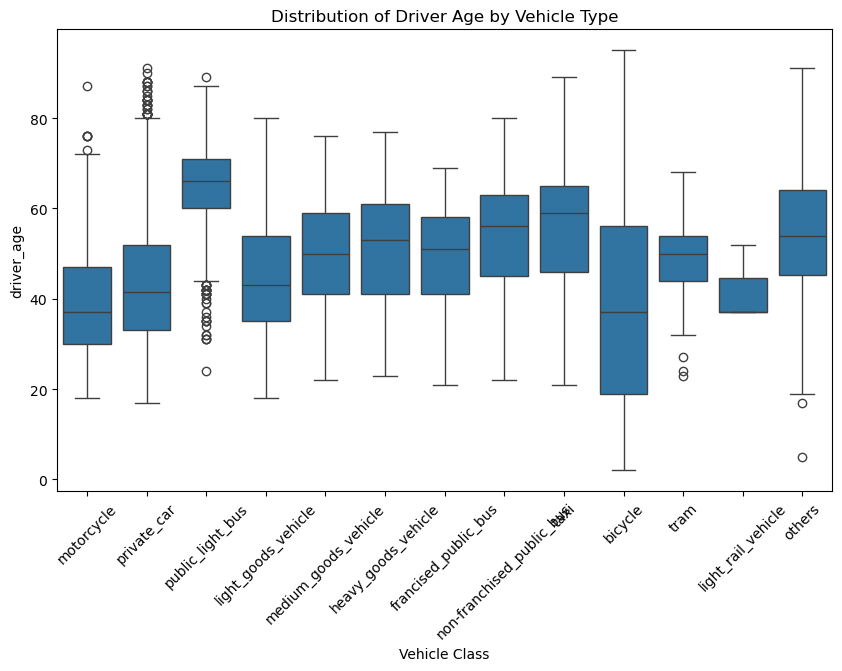

In [44]:
# check the distribution of driver age by vehicle types apart from those unknown (i.e. age == 999)
display(df_vehicle[df_vehicle['driver_age'] != 999].groupby('Vehicle Class')['driver_age'].describe())

# Get the order of vehicle classes based on their numerical codes
sorted_vehicle_classes = [veh_class_mapping[key] for key in sorted(veh_class_mapping.keys())]

# display age distribution graphically by vehicle types
plt.figure(figsize=(10, 6))
sns.boxplot(x='Vehicle Class', y='driver_age', data=df_vehicle[df_vehicle['driver_age'] != 999], order=sorted_vehicle_classes)
plt.title('Distribution of Driver Age by Vehicle Type')
plt.xticks(rotation=45)
plt.show()

In [45]:
# fill in missing age according to median by vehicle groups
df_vehicle['driver_age'] = df_vehicle['driver_age'].replace(999, np.nan)
df_vehicle['driver_age'] = df_vehicle.groupby('Vehicle Class')['driver_age'].transform(lambda x: x.fillna(x.median()))

In [46]:
# Verify the numeric driver_age column
df_vehicle['driver_age'].describe()

count    31315.000000
mean        46.570845
std         14.589014
min          2.000000
25%         35.000000
50%         46.000000
75%         59.000000
max         95.000000
Name: driver_age, dtype: float64

In [47]:
# Vehicle class count in df_vehicle
veh_class_names = ['motorcycle', 'private_car', 'public_light_bus', 'light_goods_vehicle', 'medium_goods_vehicle', 'heavy_goods_vehicle', 'francised_public_bus', 'non-franchised_public_bus', 'taxi', 'bicycle','tram', 'light_rail_vehicle', 'others']
# Corrected: Use value_counts on the 'Vehicle Class' column to get the counts of each vehicle type
print(df_vehicle['Vehicle Class'].value_counts().reindex(veh_class_names, fill_value=0))

Vehicle Class
motorcycle                    2838
private_car                  12296
public_light_bus               917
light_goods_vehicle           3469
medium_goods_vehicle           947
heavy_goods_vehicle            314
francised_public_bus          1993
non-franchised_public_bus      425
taxi                          5714
bicycle                       2023
tram                            41
light_rail_vehicle               3
others                         335
Name: count, dtype: int64


In [48]:
# vehicle age distribution
df_vehicle['veh_age'].groupby(df_vehicle['Vehicle Class']).describe()

,count,mean,std,min,25%,50%,75%,max
Vehicle Class,,,,,,,,
bicycle,104.0,5.144231,4.075545,0.0,4.0,4.0,4.0,24.0
francised_public_bus,1942.0,8.594748,3.224237,0.0,6.0,9.0,11.0,20.0
heavy_goods_vehicle,314.0,7.098726,3.833574,0.0,3.0,8.0,10.0,15.0
light_goods_vehicle,3450.0,7.243478,3.672181,0.0,4.0,7.0,10.0,24.0
light_rail_vehicle,3.0,16.666667,18.147543,0.0,7.0,14.0,25.0,36.0
medium_goods_vehicle,944.0,7.784958,3.659608,0.0,5.0,8.0,10.0,30.0
motorcycle,2827.0,6.281924,5.355128,0.0,3.0,4.0,9.0,59.0
non-franchised_public_bus,421.0,7.741093,3.919663,0.0,5.0,8.0,11.0,17.0
others,259.0,8.158301,5.631621,0.0,4.0,7.0,10.5,33.0


Text(0.5, 1.0, 'Distribution of Vehicle Age by Vehicle Type')

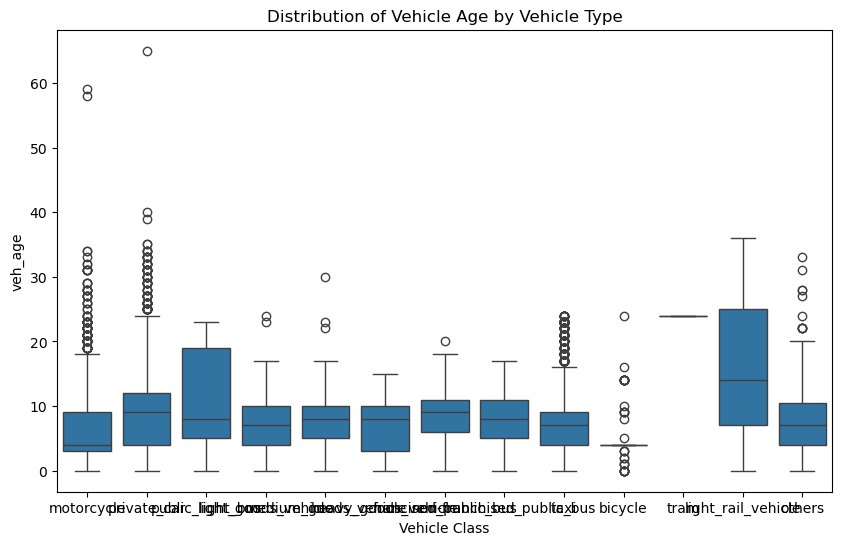

In [49]:
# vehicle age graph
plt.figure(figsize=(10, 6))
sns.boxplot(x='Vehicle Class', y='veh_age', data=df_vehicle, order=sorted_vehicle_classes)
plt.title('Distribution of Vehicle Age by Vehicle Type')

In [50]:
# Check missing vehicle age
df_vehicle[df_vehicle['veh_age'].isna()]

,Serial,Driver Sex,Severity of Accident,Vehicle Class,driver_age,year_of_manuf,veh_age
10,7,1,3,bicycle,13.0,NaN,NaN
27,18,1,3,bicycle,62.0,NaN,NaN
38,24,9,3,taxi,59.0,NaN,NaN
55,34,1,3,bicycle,21.0,NaN,NaN
57,36,1,3,bicycle,58.0,NaN,NaN
...,...,...,...,...,...,...,...
31283,18336,1,3,bicycle,29.0,NaN,NaN
31289,18339,2,3,bicycle,18.0,NaN,NaN
31310,18352,9,3,others,54.0,NaN,NaN
31311,18353,1,3,bicycle,52.0,NaN,NaN


In [51]:
# fill missing vehicle age by vehicle class median
df_vehicle['veh_age'] = df_vehicle.groupby('Vehicle Class')['veh_age'].transform(lambda x: x.fillna(x.median()))

In [52]:
# 3. Vehicle Class Dummies
veh_class_dummies = pd.get_dummies(df_vehicle['Vehicle Class'])
veh_class_cols = veh_class_dummies.columns.tolist()
veh_class_dummies = veh_class_dummies.astype(int)
df_vehicle = pd.concat([df_vehicle, veh_class_dummies], axis=1)

# Create binary flags for age groups and vehicle age
df_vehicle['is_young_driver'] = (df_vehicle['driver_age'] < 25).astype(int)
df_vehicle['is_old_driver'] = (df_vehicle['driver_age'] > 65).astype(int)
df_vehicle['is_old_vehicle'] = (df_vehicle['veh_age'] > 10).astype(int)

# 4. Aggregate features by Serial
# For binary flags, 'max' acts as an OR: 1 if at least one vehicle/driver fits the criteria
named_agg_rules = {
    'has_young_driver': pd.NamedAgg(column='is_young_driver', aggfunc='max'),
    'has_old_driver': pd.NamedAgg(column='is_old_driver', aggfunc='max'),
    'has_old_vehicle': pd.NamedAgg(column='is_old_vehicle', aggfunc='max')
}

for col in veh_class_cols:
    named_agg_rules[col] = pd.NamedAgg(column=col, aggfunc='max')

vehicle_features = df_vehicle.groupby('Serial').agg(**named_agg_rules)

# 5. Merge with main dataframe (df)
df = df.merge(vehicle_features, left_on='serial', right_index=True, how='left')

# 6. Verify first few rows
df.head()

,serial,severity,district,hit_and_run,weather,rain,natural_light,junction_control,road_classification,vehicle_movements,type_of_collision,num_vehicles_involved,date,datetime,am_pm,time_slot,is_holiday,has_young_driver,has_old_driver,has_old_vehicle,bicycle,francised_public_bus,heavy_goods_vehicle,light_goods_vehicle,light_rail_vehicle,medium_goods_vehicle,motorcycle,non-franchised_public_bus,others,private_car,public_light_bus,taxi,tram
0,1,0,WCH,2,1,1,3,6,2,1,1,1,2024-01-01,2024-01-01 00:17:00,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
1,2,0,WCH,2,1,1,3,6,2,1,1,1,2024-01-01,2024-01-01 00:30:00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,3,0,WCH,2,1,1,3,6,2,1,4,1,2024-01-01,2024-01-01 00:59:00,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,4,0,KT,2,1,1,3,6,2,5,2,3,2024-01-01,2024-01-01 03:54:00,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0
4,5,0,SK,2,1,1,3,2,2,2,2,2,2024-01-01,2024-01-01 04:04:00,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18354 entries, 0 to 18353
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   serial                     18354 non-null  int64         
 1   severity                   18354 non-null  category      
 2   district                   18354 non-null  category      
 3   hit_and_run                18354 non-null  category      
 4   weather                    18354 non-null  category      
 5   rain                       18354 non-null  category      
 6   natural_light              18354 non-null  category      
 7   junction_control           18354 non-null  category      
 8   road_classification        18354 non-null  category      
 9   vehicle_movements          18354 non-null  category      
 10  type_of_collision          18354 non-null  category      
 11  num_vehicles_involved      18354 non-null  int64         
 12  date

In [54]:
# group similar types of vehicles
df['public_bus'] = df['non-franchised_public_bus'] + df['francised_public_bus']
df['goods_vehicle'] = df['light_goods_vehicle'] + df['medium_goods_vehicle'] + df['heavy_goods_vehicle']
df['light_rail'] = df['light_rail_vehicle'] + df['tram']

# drop old types
df = df.drop(columns=['non-franchised_public_bus', 'francised_public_bus', 'light_goods_vehicle', 'medium_goods_vehicle', 'heavy_goods_vehicle', 'light_rail_vehicle', 'tram'])

In [55]:
# Vehicle class count
veh_class_names = ['motorcycle', 'private_car', 'public_light_bus', 'taxi', 'bicycle', 'others', 'public_bus', 'goods_vehicle', 'light_rail']
print(df[veh_class_names].sum())

motorcycle          2794
private_car         9211
public_light_bus     882
taxi                5037
bicycle             1879
others               323
public_bus          2356
goods_vehicle       4364
light_rail            38
dtype: int64


In [56]:
# remove bicycle-only cases

# List of all vehicle type columns
vehicle_type_cols = ['motorcycle', 'private_car', 'public_light_bus', 'taxi', 'bicycle', 'others', 'public_bus', 'goods_vehicle', 'light_rail']

# Calculate the total number of vehicles involved based on dummy columns
vehicle_sum = df[vehicle_type_cols].sum(axis=1)

# Identify 'bicycle-only' cases: only 1 vehicle type involved AND that type is a bicycle
bicycle_only_cases = (df['bicycle'] == 1) & (vehicle_sum == 1)

# Filter the DataFrame to remove these 'bicycle-only' cases
df = df[~bicycle_only_cases]

print(f"Removed {bicycle_only_cases.sum()} bicycle-only cases.")
print(f"New DataFrame shape: {df.shape}")

Removed 1508 bicycle-only cases.
New DataFrame shape: (16846, 29)


In [57]:
# Remove rows that involve 'others' or 'light_rail'
mask = (df['others'] == 1) | (df['light_rail'] == 1)
df = df[~mask]

df.drop(columns=['others', 'light_rail'], inplace=True)

print(f"Removed {mask.sum()} rows involving 'others' or 'light_rail'.")
print(f"New DataFrame shape: {df.shape}")

Removed 361 rows involving 'others' or 'light_rail'.
New DataFrame shape: (16485, 27)


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16485 entries, 0 to 18353
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   serial                 16485 non-null  int64         
 1   severity               16485 non-null  category      
 2   district               16485 non-null  category      
 3   hit_and_run            16485 non-null  category      
 4   weather                16485 non-null  category      
 5   rain                   16485 non-null  category      
 6   natural_light          16485 non-null  category      
 7   junction_control       16485 non-null  category      
 8   road_classification    16485 non-null  category      
 9   vehicle_movements      16485 non-null  category      
 10  type_of_collision      16485 non-null  category      
 11  num_vehicles_involved  16485 non-null  int64         
 12  date                   16485 non-null  datetime64[ns]
 13  dateti

In [59]:
# Identify unknown weather (code 9) and replace based on date and district
if df['weather'].dtype.name == 'category':
    df['weather'] = df['weather'].astype(int)

# 1. Mode by Date and District
def fill_weather_mode_district(group):
    valid_weather = group[group != 9]
    if not valid_weather.empty:
        mode_val = valid_weather.mode()[0]
        return group.replace(9, mode_val)
    return group

df['weather'] = df.groupby(['date', 'district'], group_keys=False)['weather'].apply(fill_weather_mode_district)

# 2.Mode by Date
def fill_weather_mode_date(group):
    valid_weather = group[group != 9]
    if not valid_weather.empty:
        mode_val = valid_weather.mode()[0]
        return group.replace(9, mode_val)
    return group

df['weather'] = df.groupby(['date'], group_keys=False)['weather'].apply(fill_weather_mode_date)

# Convert back to categorical
df['weather'] = df['weather'].astype('category')

# Verify if any 9 remain
remaining_unknown = (df['weather'].astype(int) == 9).sum()
print(f'Remaining unknown weather records: {remaining_unknown}')
print(df['weather'].value_counts())

C:\Users\Ewan\AppData\Local\Temp\ipykernel_33652\859079330.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['weather'] = df.groupby(['date', 'district'], group_keys=False)['weather'].apply(fill_weather_mode_district)


Remaining unknown weather records: 0
weather
1    16026
2      365
3       81
4       13
Name: count, dtype: int64


In [60]:
# Identify unknown rain and replace based on date and district
if df['rain'].dtype.name == 'category':
    df['rain'] = df['rain'].astype(int)

# 1. Mode by Date and District
def fill_rain_mode_district(group):
    valid_rain = group[group != 9]
    if not valid_rain.empty:
        mode_val = valid_rain.mode()[0]
        return group.replace(9, mode_val)
    return group

df['rain'] = df.groupby(['date', 'district'], group_keys=False, observed=True)['rain'].apply(fill_rain_mode_district)

# 2. Mode by Date (fallback)
def fill_rain_mode_date(group):
    valid_rain = group[group != 9]
    if not valid_rain.empty:
        mode_val = valid_rain.mode()[0]
        return group.replace(9, mode_val)
    return group

df['rain'] = df.groupby(['date'], group_keys=False)['rain'].apply(fill_rain_mode_date)

# Convert back to categorical
df['rain'] = df['rain'].astype('category')

# Verify results
remaining_rain_unknown = (df['rain'].astype(int) == 9).sum()
print(f'Remaining unknown rain records: {remaining_rain_unknown}')
print(df['rain'].value_counts())

Remaining unknown rain records: 0
rain
1    15258
2     1049
3      178
Name: count, dtype: int64


In [61]:
# Check natural light with pivottable based on timeslot
# Using 'count' on a single column (serial) to avoid redundant tables
pivot_table = pd.pivot_table(
    df,
    values='serial',
    index='natural_light',
    columns='time_slot',
    aggfunc='count',
    fill_value=0,
    observed=False
)

display(pivot_table)

time_slot,0,1,2,3
natural_light,,,,
1,3289,955,3175,3419
2,154,473,93,7
3,955,2729,1107,26
9,30,33,25,15


In [62]:
# Identify unknown natural light and replace based on date and time_slot
if df['natural_light'].dtype.name == 'category':
    df['natural_light'] = df['natural_light'].astype(int)

# 1. Mode by Date and time_slot
def fill_light_mode_datetime(group):
    valid_light = group[group != 9]
    if not valid_light.empty:
        mode_val = valid_light.mode()[0]
        return group.replace(9, mode_val)
    return group

df['natural_light'] = df.groupby(['date', 'time_slot'], group_keys=False, observed=False)['natural_light'].apply(fill_light_mode_datetime)

# 2. Mode by time_slot
def fill_light_mode_slot(group):
    valid_light = group[group != 9]
    if not valid_light.empty:
        mode_val = valid_light.mode()[0]
        return group.replace(9, mode_val)
    return group

df['natural_light'] = df.groupby(['time_slot'], group_keys=False, observed=False)['natural_light'].apply(fill_light_mode_slot)

# Convert back to categorical
df['natural_light'] = df['natural_light'].astype('category')

# Verify results
remaining_light_unknown = (df['natural_light'].astype(int) == 9).sum()
print(f'Remaining unknown natural light records: {remaining_light_unknown}')
print(df['natural_light'].value_counts())

Remaining unknown natural light records: 0
natural_light
1    10911
3     4847
2      727
Name: count, dtype: int64


In [63]:
# Final cleanup: Drop the columns used for imputation
df = df.drop(columns=["date", "datetime", "serial"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16485 entries, 0 to 18353
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   severity               16485 non-null  category
 1   district               16485 non-null  category
 2   hit_and_run            16485 non-null  category
 3   weather                16485 non-null  category
 4   rain                   16485 non-null  category
 5   natural_light          16485 non-null  category
 6   junction_control       16485 non-null  category
 7   road_classification    16485 non-null  category
 8   vehicle_movements      16485 non-null  category
 9   type_of_collision      16485 non-null  category
 10  num_vehicles_involved  16485 non-null  int64   
 11  am_pm                  16485 non-null  category
 12  time_slot              16485 non-null  category
 13  is_holiday             16485 non-null  category
 14  has_young_driver       16485 non-null  int6

In [64]:
# Regroup variables IN-PLACE (no duplicate columns)
remap_cfg = {
    "junction_control": {6: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 1},
    "vehicle_movements":{1: 1, 2: 2, 3: 2, 4: 2, 5: 3, 6: 3, 7: 3},
}
for col, mapping in remap_cfg.items():
    df[col] = df[col].astype(int).map(mapping).astype("category")

df["type_of_collision"] = df["type_of_collision"].astype(int).astype("category")

print(df['junction_control'].value_counts())
print(df['vehicle_movements'].value_counts())

junction_control
0    15307
1     1178
Name: count, dtype: int64
vehicle_movements
2    9642
1    5611
3    1232
Name: count, dtype: int64


## Univariate Analysis

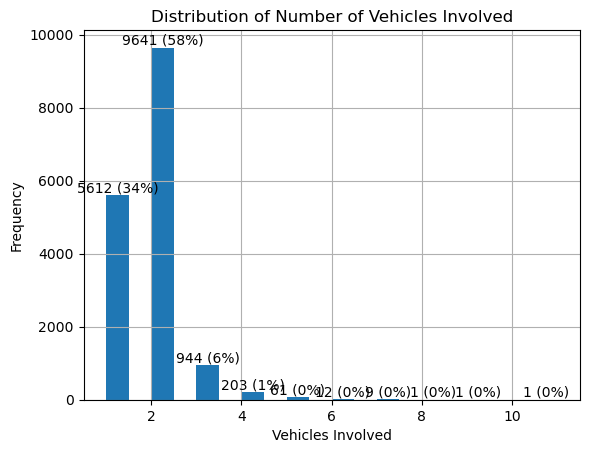

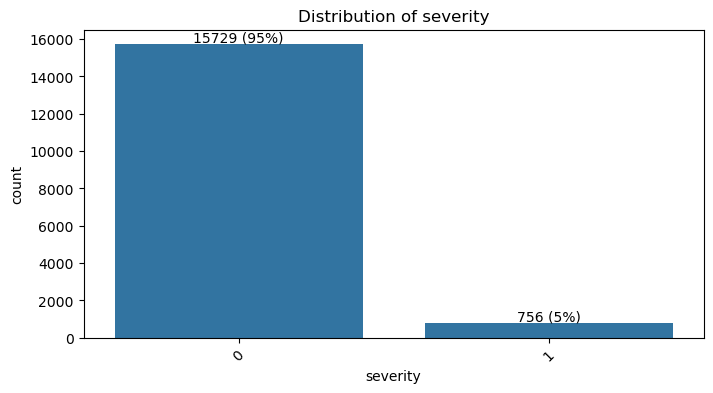

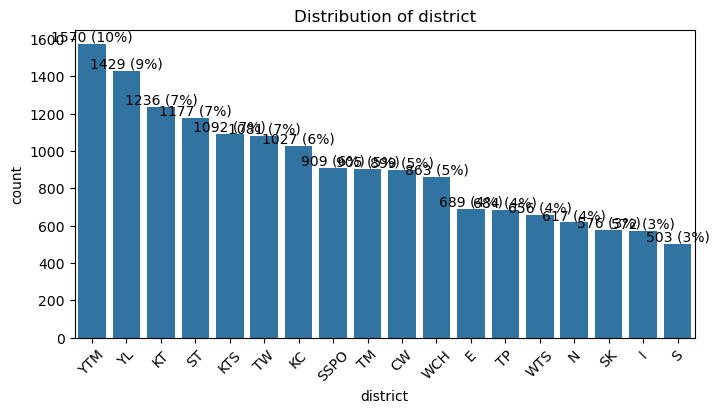

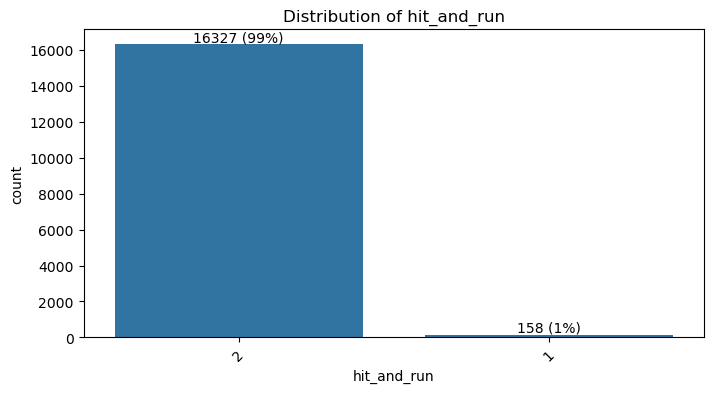

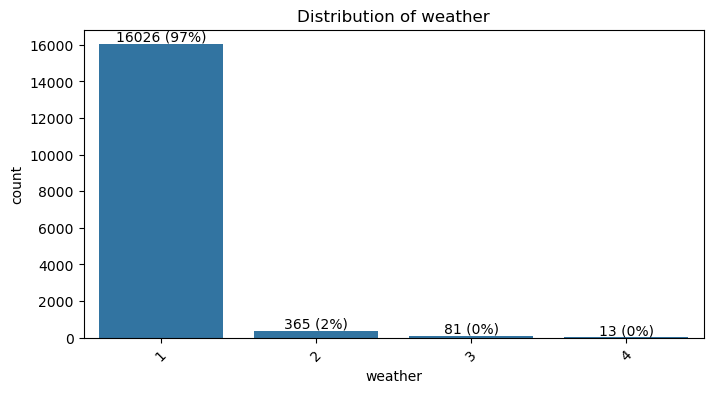

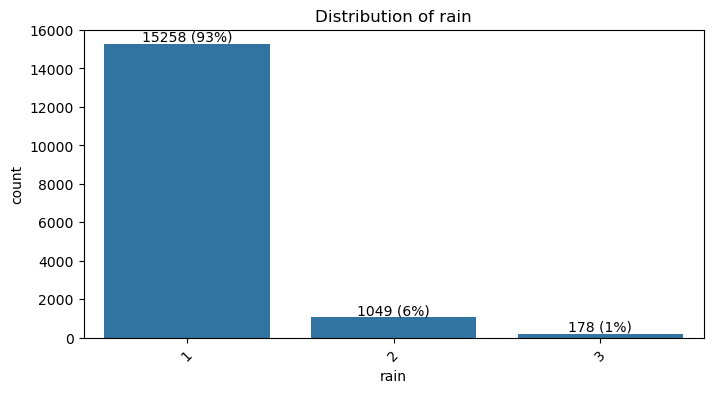

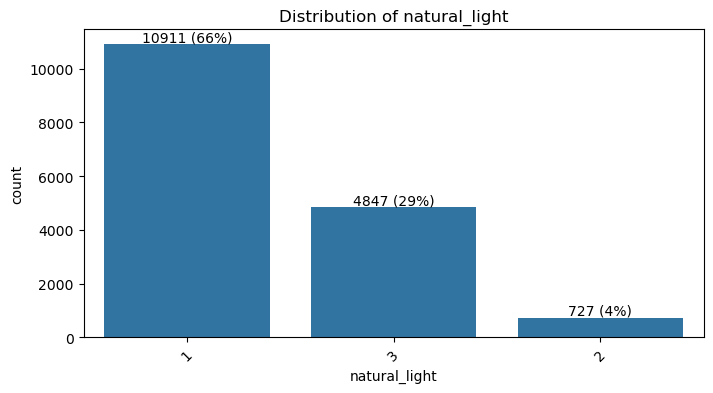

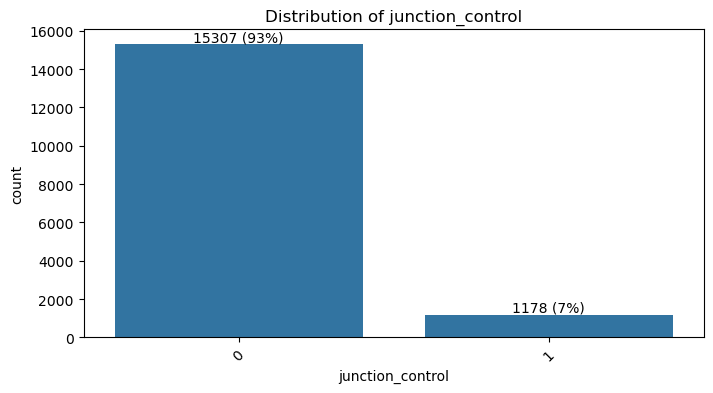

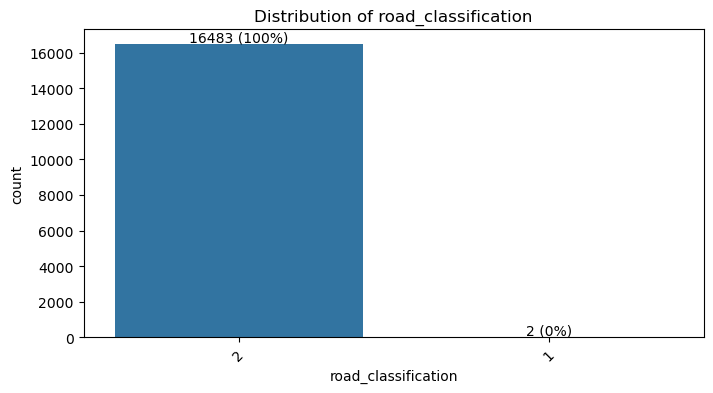

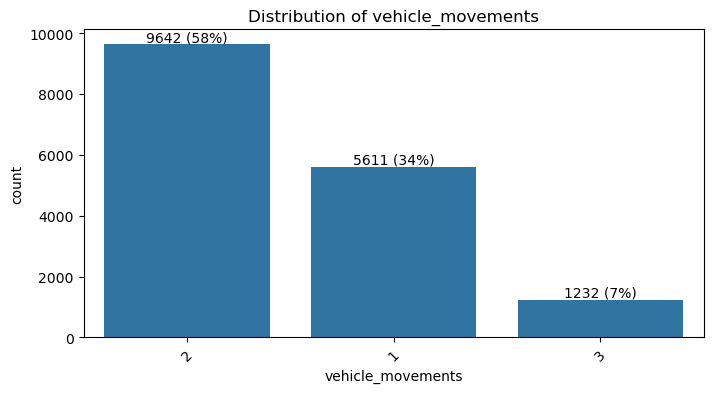

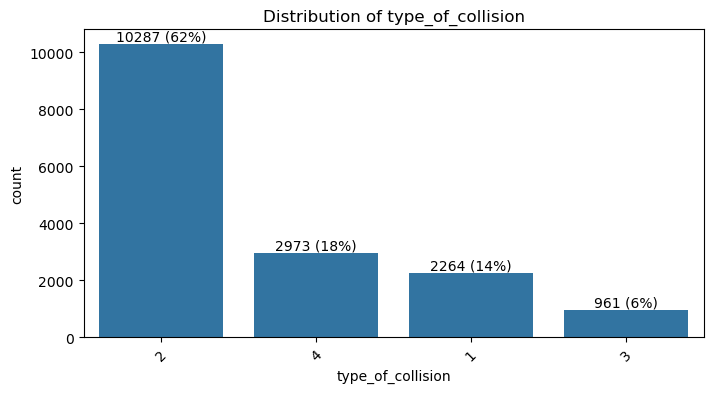

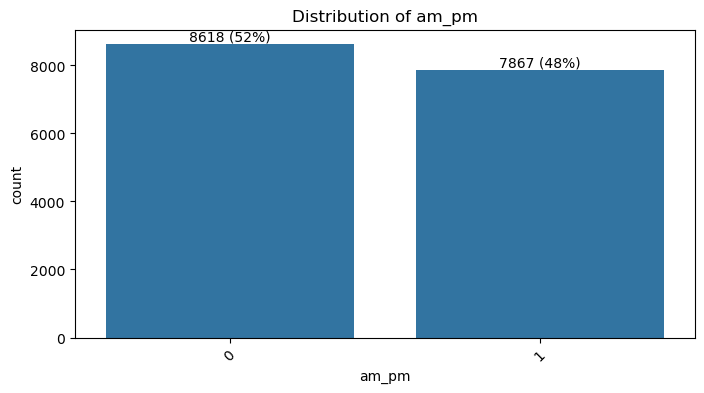

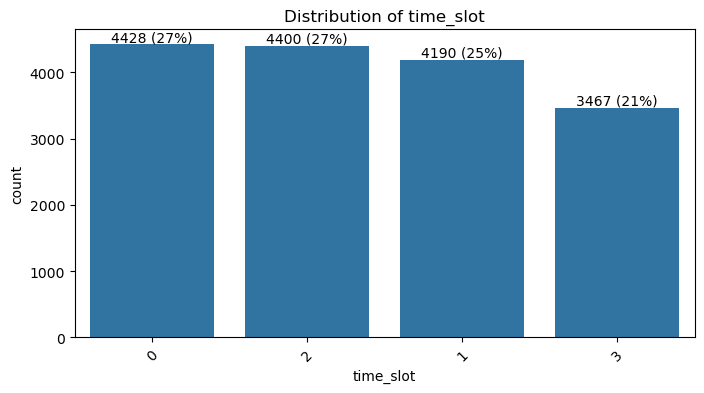

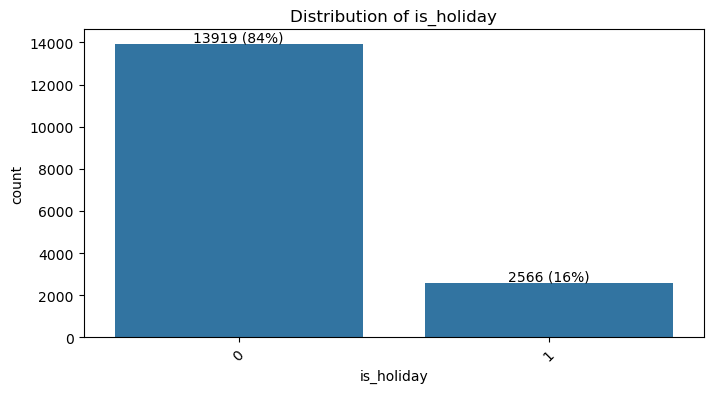

In [65]:
# Histogram for numeric variables
ax = df["num_vehicles_involved"].hist(bins=20)
plt.title("Distribution of Number of Vehicles Involved")
plt.xlabel("Vehicles Involved")
plt.ylabel("Frequency")

total = len(df)

# Annotate counts and percentages
for patch in ax.patches:
    bin_center = patch.get_x() + patch.get_width()/2
    count = int(patch.get_height())
    if count > 0:
        percent = int(round((count/total)*100, 0))
        ax.text(bin_center, count, f"{count} ({percent}%)",
                ha="center", va="bottom")

plt.show()

total = len(df)

for col in df.select_dtypes(include="category").columns:
    plt.figure(figsize=(8,4))
    ax = sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

    # Annotate counts and percentages
    for p in ax.patches:
        height = int(p.get_height())
        percent = int(round((height/total)*100, 0))
        ax.annotate(f'{height} ({percent}%)',
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom')

    plt.show()

## Bivariate Analysis


Variable: district
severity     0   1
district          
CW         835  64
E          624  65
I          531  41
KC        1006  21
KT        1207  29
KTS       1019  73
N          582  35
S          454  49
SK         561  15
SSPO       886  23
ST        1115  62
TM         890  15
TP         655  29
TW         995  86
WCH        815  48
WTS        635  21
YL        1384  45
YTM       1535  35
Chi-square p-value: 3.997325158715455e-38
Significant association between district and severity.


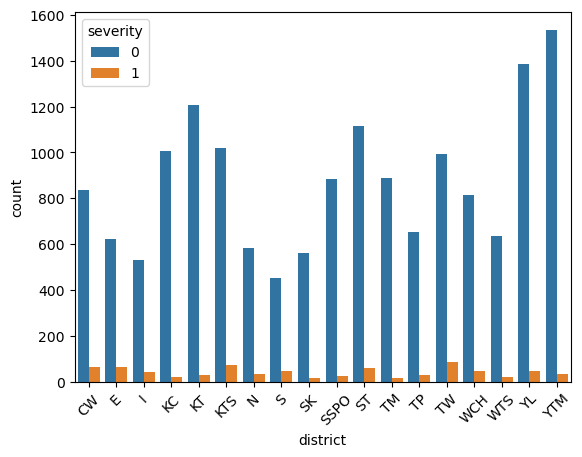


Variable: hit_and_run
severity         0    1
hit_and_run            
1              147   11
2            15582  745
Chi-square p-value: 0.2136512760386392
No significant association between hit_and_run and severity.


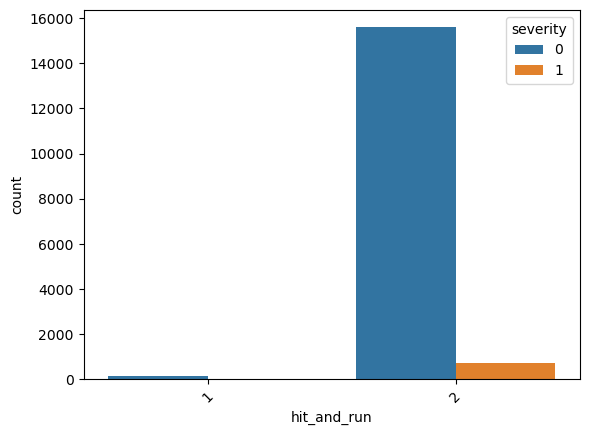


Variable: weather
severity      0    1
weather             
1         15281  745
2           359    6
3            76    5
4            13    0
Chi-square p-value: 0.037475803866920475
Significant association between weather and severity.


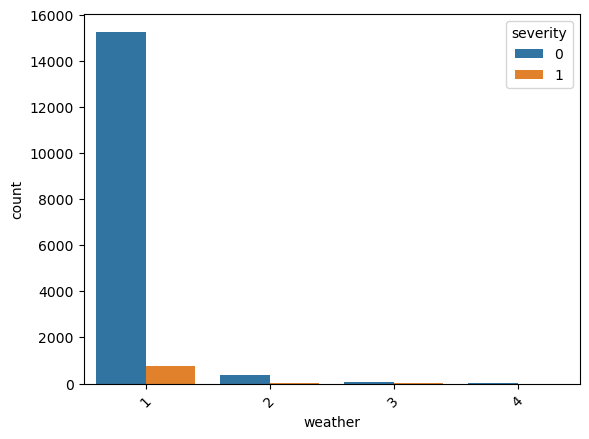


Variable: rain
severity      0    1
rain                
1         14556  702
2           998   51
3           175    3
Chi-square p-value: 0.16426093007060658
No significant association between rain and severity.


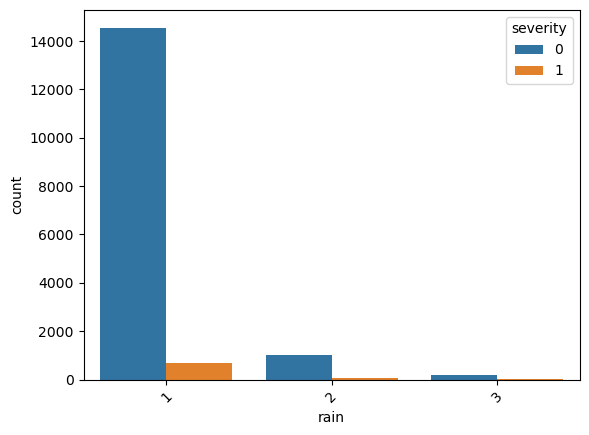


Variable: natural_light
severity           0    1
natural_light            
1              10394  517
2                702   25
3               4633  214
Chi-square p-value: 0.21343730504338412
No significant association between natural_light and severity.


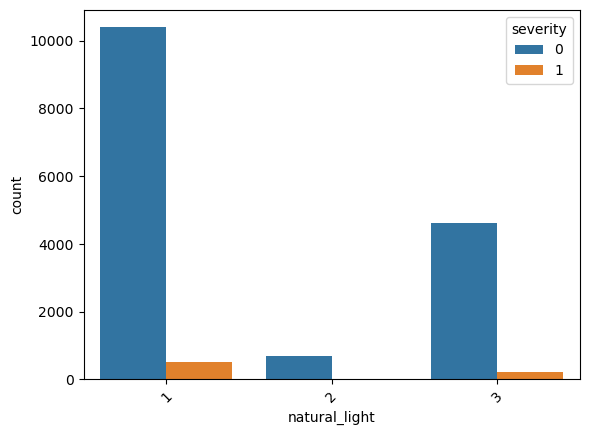


Variable: junction_control
severity              0    1
junction_control            
0                 14586  721
1                  1143   35
Chi-square p-value: 0.007419502519957132
Significant association between junction_control and severity.


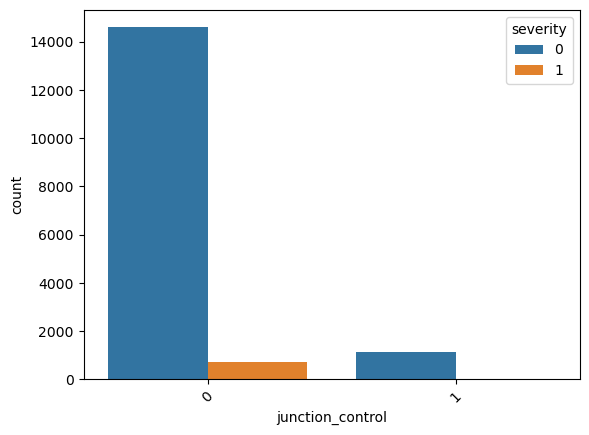


Variable: road_classification
severity                 0    1
road_classification            
1                        2    0
2                    15727  756
Chi-square p-value: 1.0
No significant association between road_classification and severity.


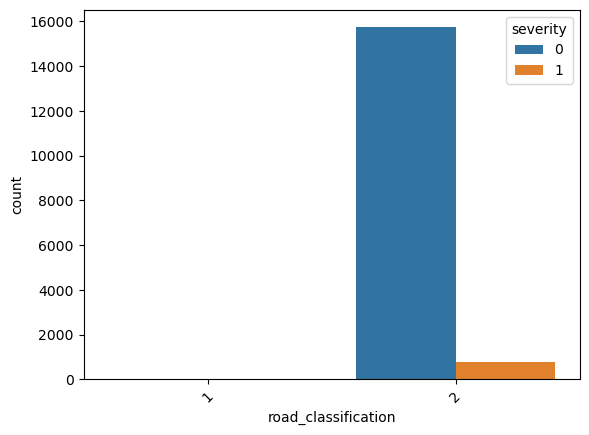


Variable: vehicle_movements
severity              0    1
vehicle_movements           
1                  5179  432
2                  9374  268
3                  1176   56
Chi-square p-value: 2.493581060466317e-43
Significant association between vehicle_movements and severity.


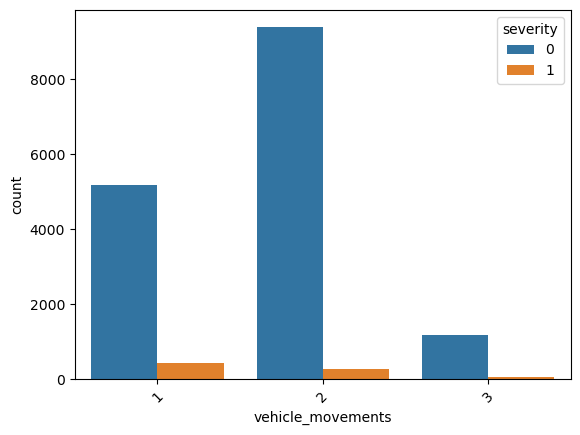


Variable: type_of_collision
severity              0    1
type_of_collision           
1                  1988  276
2                  9989  298
3                   908   53
4                  2844  129
Chi-square p-value: 1.3856808238337344e-79
Significant association between type_of_collision and severity.


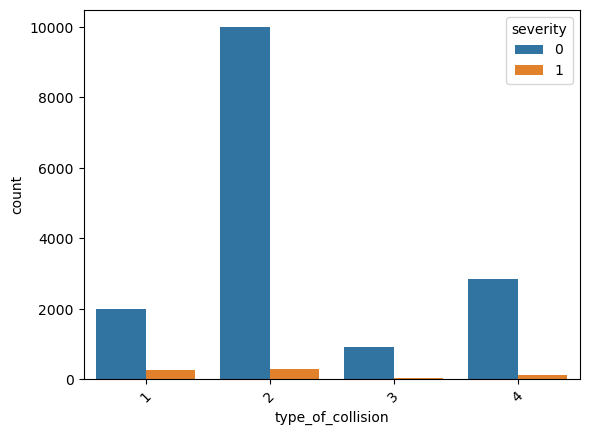


Variable: am_pm
severity     0    1
am_pm              
0         8225  393
1         7504  363
Chi-square p-value: 0.8979554062758882
No significant association between am_pm and severity.


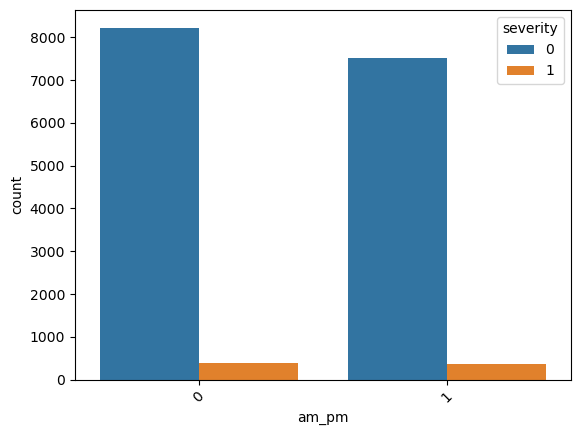


Variable: time_slot
severity      0    1
time_slot           
0          4230  198
1          3995  195
2          4205  195
3          3299  168
Chi-square p-value: 0.8133142881649662
No significant association between time_slot and severity.


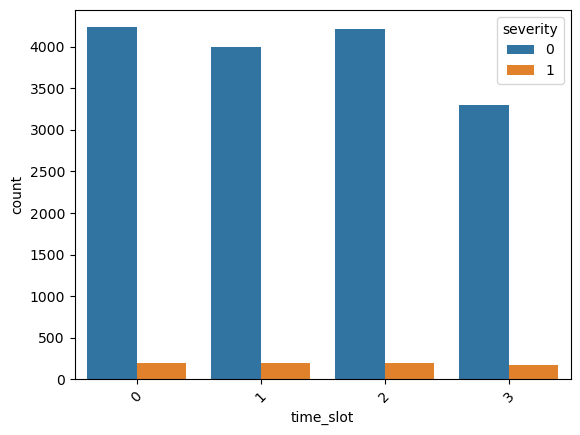


Variable: is_holiday
severity        0    1
is_holiday            
0           13294  625
1            2435  131
Chi-square p-value: 0.18782571939898518
No significant association between is_holiday and severity.


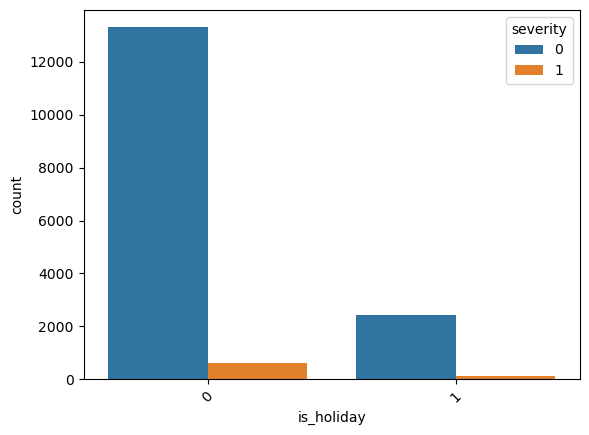

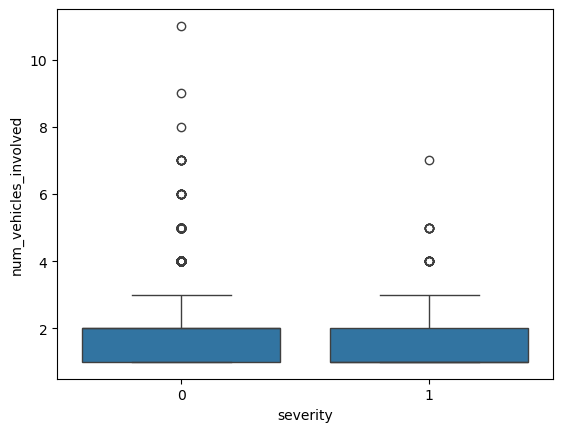

In [66]:
categorical_vars = [
    "district", "hit_and_run", "weather", "rain", "natural_light",
    "junction_control", "road_classification", "vehicle_movements",
    "type_of_collision", "am_pm", "time_slot", "is_holiday"
]

numeric_vars = ["num_vehicles_involved"]

drop_cols = []

for var in categorical_vars:
    print(f"\nVariable: {var}")
    ct = pd.crosstab(df[var], df["severity"])
    print(ct)

    # Chi-square test
    chi_2, p, dof, ex = chi2_contingency(ct)
    print(f"Chi-square p-value: {p}")
    if p < 0.05:
        print(f"Significant association between {var} and severity.")
    else:
        print(f"No significant association between {var} and severity.")
        drop_cols.append(var)

    # Visualization
    sns.countplot(x=var, hue="severity", data=df)
    plt.xticks(rotation=45)
    plt.show()

for var in numeric_vars:
    sns.boxplot(x="severity", y=var, data=df)
    plt.show()

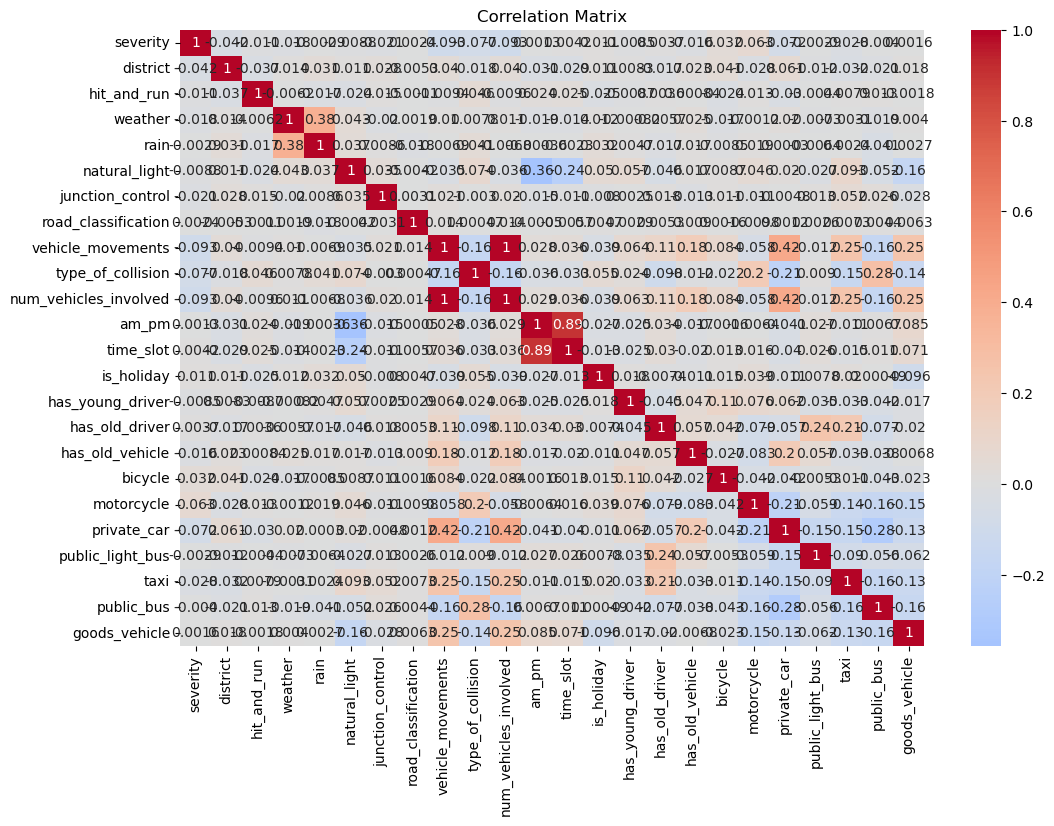

In [67]:
# Copy dataframe to avoid modifying original
df_encoded = df.copy()

# Encode categorical variables as integers
for col in df_encoded.select_dtypes(include="category").columns:
    df_encoded[col] = df_encoded[col].cat.codes

# Compute correlation matrix
corr_matrix = df_encoded.corr(method="spearman")  # Spearman works well for ordinal/categorical codes

# Focus only on correlation with severity
severity_corr = corr_matrix["severity"].drop("severity")

# heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## Variance Inflation Factor (VIF)

In [68]:
def cal_vif(pname,df):
  vif_series = pd.Series(
      [variance_inflation_factor(df[pname].values, i) for i in range(len(pname))],
      index = pname,dtype = float)
  output={}
  output['vif'] = vif_series
  output['VIF'] = vif_series.mean()
  return output

In [69]:
# Identify categorical columns
cat_cols = [col for col in df.select_dtypes(include=['category', 'object']).columns if col != 'severity']

# Create dummy variables for all categorical predictors
df_dummies = pd.get_dummies(df.drop(columns=['severity']), columns=cat_cols, drop_first=True)

print(f"Original shape: {df.shape}")
print(f"Encoded features shape: {df_dummies.shape}")
display(df_dummies.head())

Original shape: (16485, 24)
Encoded features shape: (16485, 48)


,num_vehicles_involved,has_young_driver,has_old_driver,has_old_vehicle,bicycle,motorcycle,private_car,public_light_bus,taxi,public_bus,goods_vehicle,district_E,district_I,district_KC,district_KT,district_KTS,district_N,district_S,district_SK,district_SSPO,district_ST,district_TM,district_TP,district_TW,district_WCH,district_WTS,district_YL,district_YTM,hit_and_run_2,weather_2,weather_3,weather_4,rain_2,rain_3,natural_light_2,natural_light_3,junction_control_1,road_classification_2,vehicle_movements_2,vehicle_movements_3,type_of_collision_2,type_of_collision_3,type_of_collision_4,am_pm_1,time_slot_1,time_slot_2,time_slot_3,is_holiday_1
0,1,0,0,1,0,1,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True
1,1,0,0,0,0,0,0,0,1,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True
2,1,0,0,0,0,1,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,True
3,3,0,0,1,0,0,1,0,0,0,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,True,True,False,False,False,False,False,False,True
4,2,0,0,0,0,1,0,0,1,0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,True,True,False,True,False,False,False,False,False,False,True


In [70]:
# calculate vif
cal_vif(df_dummies.columns, df_dummies.astype(float))

c:\Users\Ewan\anaconda3\envs\Main\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


{'vif': num_vehicles_involved     86.419441
 has_young_driver           1.113050
 has_old_driver             1.416623
 has_old_vehicle            1.822458
 bicycle                    1.148975
 motorcycle                 2.057917
 private_car                6.799379
 public_light_bus           1.418775
 taxi                       3.056201
 public_bus                 2.083904
 goods_vehicle              2.696020
 district_E                 1.779825
 district_I                 1.651687
 district_KC                2.215146
 district_KT                2.441989
 district_KTS               2.245280
 district_N                 1.721821
 district_S                 1.573232
 district_SK                1.679783
 district_SSPO              2.056455
 district_ST                2.349393
 district_TM                2.047225
 district_TP                1.813411
 district_TW                2.237160
 district_WCH               1.962550
 district_WTS               1.760179
 district_YL                2.6

In [71]:
df = df.drop(columns=['am_pm', 'hit_and_run', 'road_classification', 'num_vehicles_involved'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16485 entries, 0 to 18353
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   severity           16485 non-null  category
 1   district           16485 non-null  category
 2   weather            16485 non-null  category
 3   rain               16485 non-null  category
 4   natural_light      16485 non-null  category
 5   junction_control   16485 non-null  category
 6   vehicle_movements  16485 non-null  category
 7   type_of_collision  16485 non-null  category
 8   time_slot          16485 non-null  category
 9   is_holiday         16485 non-null  category
 10  has_young_driver   16485 non-null  int64   
 11  has_old_driver     16485 non-null  int64   
 12  has_old_vehicle    16485 non-null  int64   
 13  bicycle            16485 non-null  int64   
 14  motorcycle         16485 non-null  int64   
 15  private_car        16485 non-null  int64   
 16  public_li

In [72]:
# Identify categorical columns
cat_cols = [col for col in df.select_dtypes(include=['category', 'object']).columns if col != 'severity']

# Create dummy variables for all categorical predictors
df_dummies = pd.get_dummies(df.drop(columns=['severity']), columns=cat_cols, drop_first=True)

print(f"Original shape: {df.shape}")
print(f"Encoded features shape: {df_dummies.shape}")
display(df_dummies.head())

Original shape: (16485, 20)
Encoded features shape: (16485, 44)


,has_young_driver,has_old_driver,has_old_vehicle,bicycle,motorcycle,private_car,public_light_bus,taxi,public_bus,goods_vehicle,district_E,district_I,district_KC,district_KT,district_KTS,district_N,district_S,district_SK,district_SSPO,district_ST,district_TM,district_TP,district_TW,district_WCH,district_WTS,district_YL,district_YTM,weather_2,weather_3,weather_4,rain_2,rain_3,natural_light_2,natural_light_3,junction_control_1,vehicle_movements_2,vehicle_movements_3,type_of_collision_2,type_of_collision_3,type_of_collision_4,time_slot_1,time_slot_2,time_slot_3,is_holiday_1
0,0,0,1,0,1,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
1,0,0,0,0,0,0,0,1,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
2,0,0,0,0,1,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True
3,0,0,1,0,0,1,0,0,0,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False,False,False,True
4,0,0,0,0,1,0,0,1,0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False,True,False,False,False,False,False,True


In [73]:
cal_vif(df_dummies.columns, df_dummies.astype(float))

{'vif': has_young_driver        1.112962
 has_old_driver          1.406287
 has_old_vehicle         1.812519
 bicycle                 1.137302
 motorcycle              1.891571
 private_car             5.537840
 public_light_bus        1.366871
 taxi                    2.590239
 public_bus              1.908955
 goods_vehicle           2.331295
 district_E              1.388010
 district_I              1.342049
 district_KC             1.646926
 district_KT             1.761857
 district_KTS            1.659829
 district_N              1.368024
 district_S              1.287681
 district_SK             1.370485
 district_SSPO           1.541635
 district_ST             1.724261
 district_TM             1.550205
 district_TP             1.439938
 district_TW             1.633216
 district_WCH            1.474854
 district_WTS            1.385008
 district_YL             1.868040
 district_YTM            1.959598
 weather_2               1.174306
 weather_3               1.060380
 weathe

# Model

## Full Model v2

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16485 entries, 0 to 18353
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   severity           16485 non-null  category
 1   district           16485 non-null  category
 2   weather            16485 non-null  category
 3   rain               16485 non-null  category
 4   natural_light      16485 non-null  category
 5   junction_control   16485 non-null  category
 6   vehicle_movements  16485 non-null  category
 7   type_of_collision  16485 non-null  category
 8   time_slot          16485 non-null  category
 9   is_holiday         16485 non-null  category
 10  has_young_driver   16485 non-null  int64   
 11  has_old_driver     16485 non-null  int64   
 12  has_old_vehicle    16485 non-null  int64   
 13  bicycle            16485 non-null  int64   
 14  motorcycle         16485 non-null  int64   
 15  private_car        16485 non-null  int64   
 16  public_li

In [75]:
# Full Model uses ALL original features from df (no variable dropping or regrouping)
X_fm_all = df.drop(["severity"], axis=1)
y_fm_all = df["severity"].astype(int)

# One-hot encode categorical variables
X_fm_enc = pd.get_dummies(X_fm_all, drop_first=True)

# Split FIRST on original imbalanced data (same random_state as improved model)
X_fm_train, X_fm_test, y_fm_train, y_fm_test = train_test_split(
    X_fm_enc, y_fm_all, test_size=0.3, stratify=y_fm_all, random_state=42
)

print(f"Full Model — Train: {len(X_fm_train)} rows  |  Test: {len(X_fm_test)} rows")
print(f"\nTrain class distribution:\n{y_fm_train.value_counts()}")
print(f"\nTest class distribution (natural imbalance preserved):\n{y_fm_test.value_counts()}")
print(f"\nEncoded feature count: {X_fm_enc.shape[1]}")

Full Model — Train: 11539 rows  |  Test: 4946 rows

Train class distribution:
severity
0    11010
1      529
Name: count, dtype: int64

Test class distribution (natural imbalance preserved):
severity
0    4719
1     227
Name: count, dtype: int64

Encoded feature count: 44


SMOTE + Scaler + Logistic Regression Pipeline (Full Model)

In [76]:
# ImbPipeline: SMOTE only on training folds, scaler fit only on training data
pipeline_fm = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_fm = cross_val_score(pipeline_fm, X_fm_train, y_fm_train, cv=cv, scoring='roc_auc')

print("Full Model — Cross-validation AUC scores:", np.round(cv_scores_fm, 4))
print(f"Mean CV AUC : {np.mean(cv_scores_fm):.4f}  ±  {np.std(cv_scores_fm):.4f}")

Full Model — Cross-validation AUC scores: [0.6807 0.7009 0.6606 0.7252 0.6723]
Mean CV AUC : 0.6879  ±  0.0228


Fit Final Full Model & Evaluate on Held-Out Test Set

In [77]:
pipeline_fm.fit(X_fm_train, y_fm_train)
y_fm_pred = pipeline_fm.predict(X_fm_test)
y_fm_prob = pipeline_fm.predict_proba(X_fm_test)[:, 1]

print("Full Model — Confusion Matrix:\n", confusion_matrix(y_fm_test, y_fm_pred))
print("\nClassification Report:\n",
      classification_report(y_fm_test, y_fm_pred,
                            target_names=["Slight (0)", "Fatal/Serious (1)"]))
print(f"Test ROC-AUC : {roc_auc_score(y_fm_test, y_fm_prob):.4f}")

Full Model — Confusion Matrix:
 [[4042  677]
 [ 155   72]]

Classification Report:
                    precision    recall  f1-score   support

       Slight (0)       0.96      0.86      0.91      4719
Fatal/Serious (1)       0.10      0.32      0.15       227

         accuracy                           0.83      4946
        macro avg       0.53      0.59      0.53      4946
     weighted avg       0.92      0.83      0.87      4946

Test ROC-AUC : 0.6605


Full Model — Coefficients

In [78]:
log_reg_fm = pipeline_fm.named_steps['clf']

coef_df_fm = pd.DataFrame({
    "Feature":     X_fm_enc.columns,
    "Coefficient": log_reg_fm.coef_[0],
    "Odds Ratio":  np.exp(log_reg_fm.coef_[0])
}).sort_values("Coefficient", ascending=False)

print(coef_df_fm.to_string(index=False))

            Feature  Coefficient  Odds Ratio
type_of_collision_2     0.055197    1.056748
          weather_3     0.016301    1.016435
            bicycle    -0.009424    0.990620
vehicle_movements_3    -0.052000    0.949329
    has_old_vehicle    -0.060534    0.941262
          weather_4    -0.111098    0.894851
         motorcycle    -0.112977    0.893171
 junction_control_1    -0.130526    0.877634
             rain_2    -0.138082    0.871027
     has_old_driver    -0.179411    0.835762
    natural_light_2    -0.182915    0.832839
          weather_2    -0.214153    0.807225
   has_young_driver    -0.227760    0.796315
             rain_3    -0.237684    0.788451
       is_holiday_1    -0.244445    0.783139
        time_slot_1    -0.311808    0.732122
    natural_light_3    -0.337211    0.713758
         district_I    -0.502582    0.604967
   public_light_bus    -0.509429    0.600838
         district_S    -0.536997    0.584501
type_of_collision_3    -0.544218    0.580296
        ti

## Univariate Analysis (After SMOTE on Training Data)

Since SMOTE is now applied **inside the pipeline** on training folds only, we demonstrate
the effect of SMOTE by resampling the Full Model training set once and visualising the result.

Class distribution after SMOTE on training set:
severity
0    11010
1    11010
Name: count, dtype: int64


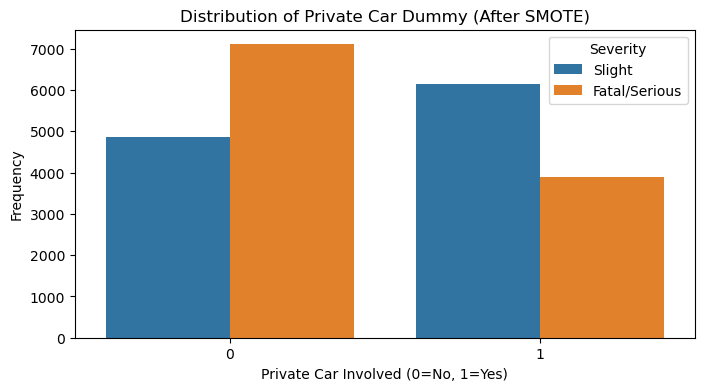

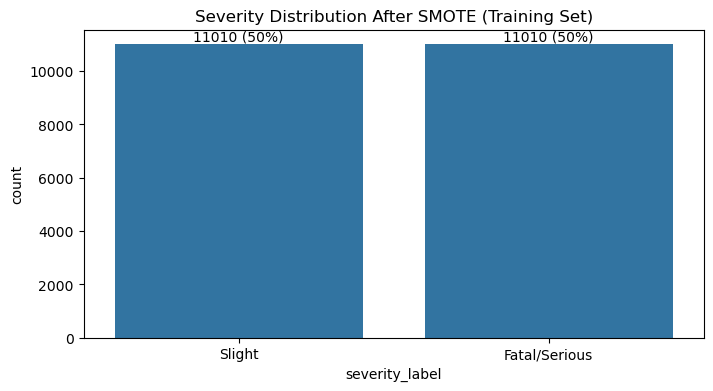

In [79]:
# Apply SMOTE once on the Full Model training set to visualise the balanced distribution
smote = SMOTE(random_state=42)
X_vis, y_vis = smote.fit_resample(X_fm_train, y_fm_train)

# Rebuild a DataFrame with original column names for plotting
df_balanced_vis = pd.DataFrame(X_vis, columns=X_fm_enc.columns)
df_balanced_vis["severity"] = y_vis

print("Class distribution after SMOTE on training set:")
print(df_balanced_vis["severity"].value_counts())

plt.figure(figsize=(8, 4))
ax = sns.countplot(x="private_car", hue="severity", data=df_balanced_vis)
plt.title("Distribution of Private Car Dummy (After SMOTE)")
plt.xlabel("Private Car Involved (0=No, 1=Yes)")
plt.ylabel("Frequency")
plt.legend(title="Severity", labels=["Slight", "Fatal/Serious"])
plt.show()

# Bar charts for severity distribution
severity_map = {0: "Slight", 1: "Fatal/Serious"}
df_balanced_vis["severity_label"] = df_balanced_vis["severity"].map(severity_map)

plt.figure(figsize=(8, 4))
total = len(df_balanced_vis)
ax = sns.countplot(x="severity_label", data=df_balanced_vis, order=["Slight", "Fatal/Serious"])
plt.title("Severity Distribution After SMOTE (Training Set)")

for p in ax.patches:
    height = int(p.get_height())
    percent = int(round((height / total) * 100, 0))
    ax.annotate(f'{height} ({percent}%)', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

plt.show()

## Reduced Model

Same leakage fixes as the Full Model. Additionally:
- Drop low-signal variables (`road_classification`, `hit_and_run`, `weather`, `rain`, `is_holiday`)
- Regroup ordinal/nominal variables **in-place** (no duplicate columns)
- Use the same `ImbPipeline` approach

### Reduced Model — Split & Pipeline

In [80]:
df_red = df.copy()
X_rm_all = df_red.drop("severity", axis=1)
y_rm_all = df_red["severity"].astype(int)

# One-hot encode
X_rm_enc = pd.get_dummies(X_rm_all, drop_first=True)

# Split FIRST (same random_state for fair comparison)
X_rm_train, X_rm_test, y_rm_train, y_rm_test = train_test_split(
    X_rm_enc, y_rm_all, test_size=0.3, stratify=y_rm_all, random_state=42
)

print(f"Reduced Model — Train: {len(X_rm_train)} rows  |  Test: {len(X_rm_test)} rows")
print(f"\nEncoded feature count: {X_rm_enc.shape[1]}")

Reduced Model — Train: 11539 rows  |  Test: 4946 rows

Encoded feature count: 44


### Backward Elimination — Feature Selection

Using the **Likelihood Ratio Test (LRT)** on the **training data only** to avoid data leakage.  
At each step the feature with the highest p-value is removed until all remaining features are significant at α = 0.05.


In [81]:
# Likelihood Ratio Test (training data only, no data leakage)
def LRT_be(predictor, x, y):
    x_full = pd.get_dummies(x, drop_first=True).astype(float)
    sc1 = StandardScaler()
    Xf = sm.add_constant(sc1.fit_transform(x_full))
    fm = sm.Logit(y.astype(float), Xf).fit(disp=0)

    x_red = x.drop(columns=[predictor])
    x_red_d = pd.get_dummies(x_red, drop_first=True).astype(float)
    sc2 = StandardScaler()
    Xr = sm.add_constant(sc2.fit_transform(x_red_d))
    rm = sm.Logit(y.astype(float), Xr).fit(disp=0)

    df_diff = fm.df_model - rm.df_model
    return 1 - chi2.cdf(-2 * (rm.llf - fm.llf), df_diff)

# Get original (pre-dummy) training rows using shared index
X_rm_all_train = X_rm_all.loc[X_rm_train.index]

x_be = X_rm_all_train.copy()
step = 1

print("Backward Elimination on Reduced Model Training Data\n")
print(f"Initial features ({len(x_be.columns)}): {x_be.columns.tolist()}\n")

while True:
    max_p, max_feat = 0, None
    print(f"=== Step {step} ===")
    for feat in x_be.columns:
        p = LRT_be(feat, x_be, y_rm_train)
        print(f"  {feat}: p = {p:.4f}")
        if p > max_p:
            max_p, max_feat = p, feat

    if max_p > 0.05:
        print(f"\n  → Removing '{max_feat}' (p = {max_p:.4f})\n")
        x_be = x_be.drop(columns=[max_feat])
        step += 1
    else:
        print(f"\n  → All p-values ≤ 0.05. Stopping.")
        break

selected_features_rm = x_be.columns.tolist()
print(f"\nSelected features ({len(selected_features_rm)}): {selected_features_rm}")


Backward Elimination on Reduced Model Training Data

Initial features (19): ['district', 'weather', 'rain', 'natural_light', 'junction_control', 'vehicle_movements', 'type_of_collision', 'time_slot', 'is_holiday', 'has_young_driver', 'has_old_driver', 'has_old_vehicle', 'bicycle', 'motorcycle', 'private_car', 'public_light_bus', 'taxi', 'public_bus', 'goods_vehicle']

=== Step 1 ===


c:\Users\Ewan\anaconda3\envs\Main\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Ewan\anaconda3\envs\Main\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  district: p = 0.0000


c:\Users\Ewan\anaconda3\envs\Main\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  weather: p = 0.0276


...

c:\Users\Ewan\anaconda3\envs\Main\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  motorcycle: p = 0.0000


c:\Users\Ewan\anaconda3\envs\Main\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  public_bus: p = 0.0000
  goods_vehicle: p = 0.0001

  → All p-values ≤ 0.05. Stopping.

Selected features (10): ['district', 'weather', 'rain', 'vehicle_movements', 'type_of_collision', 'has_old_vehicle', 'bicycle', 'motorcycle', 'public_bus', 'goods_vehicle']


c:\Users\Ewan\anaconda3\envs\Main\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [82]:
# Filter encoded columns to only retain dummies from selected features
selected_dummy_cols = [
    c for c in X_rm_enc.columns
    if any(c == f or c.startswith(f + '_') for f in selected_features_rm)
]

print(f"Selected dummy columns ({len(selected_dummy_cols)}): {selected_dummy_cols}")

# Update X_rm_train and X_rm_test — downstream models (ROS, Ensemble) will use these
X_rm_train = X_rm_train[selected_dummy_cols]
X_rm_test  = X_rm_test[selected_dummy_cols]

print(f"\nUpdated X_rm_train: {X_rm_train.shape}  |  X_rm_test: {X_rm_test.shape}")

# Build and cross-validate pipeline with selected features
pipeline_rm_be = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rm_be = cross_val_score(pipeline_rm_be, X_rm_train, y_rm_train,
                                  cv=cv, scoring='roc_auc')

print("\nReduced Model (Backward Elim) — 5-Fold CV AUC:")
print(f"  Each fold : {np.round(cv_scores_rm_be, 4)}")
print(f"  Mean ± Std: {cv_scores_rm_be.mean():.4f} ± {cv_scores_rm_be.std():.4f}")


Selected dummy columns (32): ['has_old_vehicle', 'bicycle', 'motorcycle', 'public_bus', 'goods_vehicle', 'district_E', 'district_I', 'district_KC', 'district_KT', 'district_KTS', 'district_N', 'district_S', 'district_SK', 'district_SSPO', 'district_ST', 'district_TM', 'district_TP', 'district_TW', 'district_WCH', 'district_WTS', 'district_YL', 'district_YTM', 'weather_2', 'weather_3', 'weather_4', 'rain_2', 'rain_3', 'vehicle_movements_2', 'vehicle_movements_3', 'type_of_collision_2', 'type_of_collision_3', 'type_of_collision_4']

Updated X_rm_train: (11539, 32)  |  X_rm_test: (4946, 32)

Reduced Model (Backward Elim) — 5-Fold CV AUC:
  Each fold : [0.7098 0.7435 0.6802 0.7538 0.6947]
  Mean ± Std: 0.7164 ± 0.0281


In [83]:
pipeline_rm_be.fit(X_rm_train, y_rm_train)
y_rm_pred = pipeline_rm_be.predict(X_rm_test)
y_rm_prob = pipeline_rm_be.predict_proba(X_rm_test)[:, 1]

print("Reduced Model (Backward Elim) — Confusion Matrix:")
print(confusion_matrix(y_rm_test, y_rm_pred))
print("\nClassification Report:")
print(classification_report(y_rm_test, y_rm_pred,
                            target_names=["Slight (0)", "Fatal/Serious (1)"]))
print(f"Test ROC-AUC: {roc_auc_score(y_rm_test, y_rm_prob):.4f}")


Reduced Model (Backward Elim) — Confusion Matrix:
[[3689 1030]
 [ 122  105]]

Classification Report:
                   precision    recall  f1-score   support

       Slight (0)       0.97      0.78      0.86      4719
Fatal/Serious (1)       0.09      0.46      0.15       227

         accuracy                           0.77      4946
        macro avg       0.53      0.62      0.51      4946
     weighted avg       0.93      0.77      0.83      4946

Test ROC-AUC: 0.7070


In [84]:
log_reg_rm_be = pipeline_rm_be.named_steps['clf']

coef_df_rm_be = pd.DataFrame({
    "Feature":     selected_dummy_cols,
    "Coefficient": log_reg_rm_be.coef_[0],
    "Odds Ratio":  np.exp(log_reg_rm_be.coef_[0])
}).sort_values("Coefficient", ascending=False)

print(coef_df_rm_be.to_string(index=False))


            Feature  Coefficient  Odds Ratio
         motorcycle     0.348154    1.416450
            bicycle     0.107013    1.112949
    has_old_vehicle    -0.035701    0.964929
          weather_3    -0.044995    0.956003
         public_bus    -0.080027    0.923091
      goods_vehicle    -0.081225    0.921986
          weather_4    -0.106210    0.899236
             rain_2    -0.169730    0.843892
          weather_2    -0.251889    0.777331
vehicle_movements_3    -0.262240    0.769326
             rain_3    -0.293623    0.745558
         district_I    -0.304010    0.737853
        district_TW    -0.354485    0.701535
         district_E    -0.370526    0.690371
         district_S    -0.371271    0.689857
        district_TP    -0.392541    0.675339
       district_KTS    -0.403836    0.667754
         district_N    -0.448367    0.638670
        district_ST    -0.456461    0.633522
        district_SK    -0.505567    0.603163
type_of_collision_3    -0.518042    0.595686
       dis

## Model Comparison (Fair — Both Models Leak-Free)

Both models use the same methodology:
- **Split first** on the original imbalanced data (`random_state=42`, `test_size=0.3`)
- **SMOTE** applied only inside the pipeline on training folds
- **StandardScaler** fit only on training data
- Test set preserves the natural class imbalance

The only difference is in **feature sets**:
| Model | Features |
|---|---|
| **Full Model** | All original features (no dropping or regrouping) |
| **Reduced Model** | Dropped low-signal vars + regrouped ordinal vars |

In [85]:
# Additional imports needed for comparison and error analysis
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay
)

def get_model_metrics(name, y_true, y_pred, y_prob, note=""):
    yt = np.array(y_true, dtype=int)
    yp = np.array(y_pred, dtype=int)
    return {
        "Model": name,
        "Note": note,
        "Accuracy": round(accuracy_score(yt, yp), 4),
        "Precision (F/S)": round(precision_score(yt, yp, pos_label=1, zero_division=0), 4),
        "Recall (F/S)":    round(recall_score(yt, yp,    pos_label=1, zero_division=0), 4),
        "F1 macro":        round(f1_score(yt, yp, average='macro',    zero_division=0), 4),
        "ROC-AUC":         round(roc_auc_score(yt, y_prob), 4),
    }

metrics_table = pd.DataFrame([
    get_model_metrics("Full Model",
                      y_fm_test, y_fm_pred, y_fm_prob,
                      "All features, no leakage"),
    get_model_metrics("Reduced Model",
                      y_rm_test, y_rm_pred, y_rm_prob,
                      "Dropped + regrouped features, no leakage"),
])

display(metrics_table)

,Model,Note,Accuracy,Precision (F/S),Recall (F/S),F1 macro,ROC-AUC
0,Full Model,"All features, no leakage",0.8318,0.0961,0.3172,0.5271,0.6605
1,Reduced Model,"Dropped + regrouped features, no leakage",0.7671,0.0925,0.4626,0.5096,0.7070


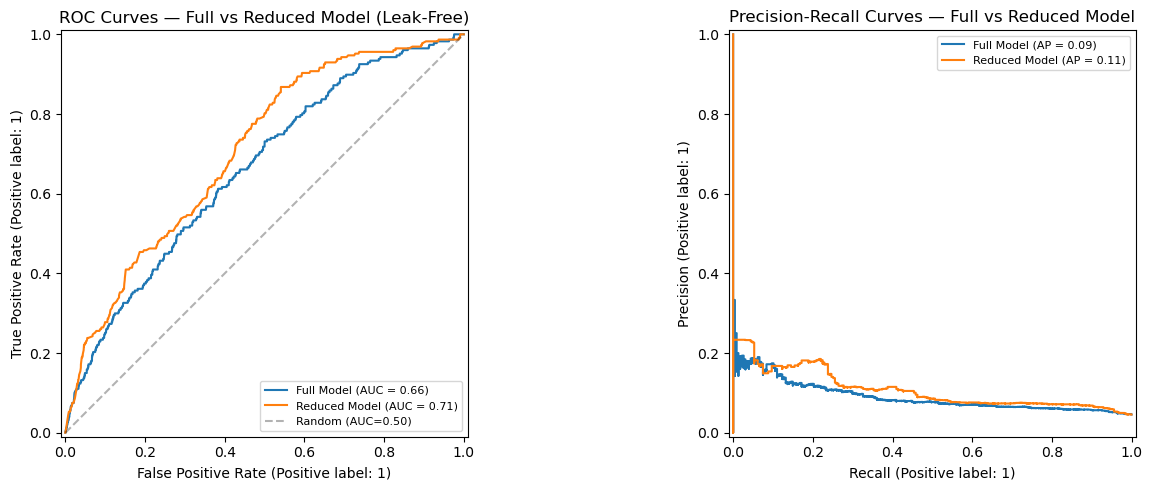

In [86]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

model_curves = [
    ("Full Model",    y_fm_test.astype(int),  y_fm_prob),
    ("Reduced Model", y_rm_test.astype(int),  y_rm_prob),
]

for label, yt, yp in model_curves:
    RocCurveDisplay.from_predictions(yt, yp, name=label, ax=ax1)
    PrecisionRecallDisplay.from_predictions(yt, yp, name=label, ax=ax2)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.50)')
ax1.set_title("ROC Curves — Full vs Reduced Model (Leak-Free)")
ax1.legend(loc='lower right', fontsize=8)

ax2.set_title("Precision-Recall Curves — Full vs Reduced Model")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Random Oversampling Model — Comparison with SMOTE

SMOTE generates **synthetic** minority instances by interpolating between nearest neighbours.  
An alternative is **Random Oversampling (ROS)**, which simply duplicates existing minority instances at random until the classes are balanced.

| Strategy | Mechanism | Risk |
|---|---|---|
| **SMOTE** | Creates *new* synthetic instances via k-NN interpolation | May introduce noise if minority instances are close to majority boundary |
| **Random Oversampling** | Duplicates *existing* minority instances | May cause overfitting to duplicated rows |

We use the same Reduced Model feature set (`df_red`) and the same train/test split to ensure a fair comparison.  
The only change is replacing `SMOTE` with `RandomOverSampler` inside the `ImbPipeline`.

In [87]:
from imblearn.over_sampling import RandomOverSampler

# ── Pipeline: RandomOverSampler + StandardScaler + LogisticRegression ──
pipeline_ros = ImbPipeline([
    ('ros',    RandomOverSampler(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

# ── Cross-validation (same folds as SMOTE model) ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_ros = cross_val_score(pipeline_ros, X_rm_train, y_rm_train,
                                cv=cv, scoring='f1')

print("Random Oversampling — 5-Fold CV F1 Scores:")
print(f"  Each fold : {cv_scores_ros.round(4)}")
print(f"  Mean ± Std: {cv_scores_ros.mean():.4f} ± {cv_scores_ros.std():.4f}")
print()

# ── Fit on full training set & evaluate on test set ──
pipeline_ros.fit(X_rm_train, y_rm_train)

y_ros_pred = pipeline_ros.predict(X_rm_test)
y_ros_prob = pipeline_ros.predict_proba(X_rm_test)[:, 1]

print("Test-set Classification Report (Random Oversampling):")
print(classification_report(y_rm_test, y_ros_pred, digits=4))

Random Oversampling — 5-Fold CV F1 Scores:
  Each fold : [0.1786 0.1855 0.1778 0.1799 0.1901]
  Mean ± Std: 0.1824 ± 0.0047

Test-set Classification Report (Random Oversampling):
              precision    recall  f1-score   support

           0     0.9744    0.7101    0.8215      4719
           1     0.0922    0.6123    0.1603       227

    accuracy                         0.7056      4946
   macro avg     0.5333    0.6612    0.4909      4946
weighted avg     0.9339    0.7056    0.7912      4946



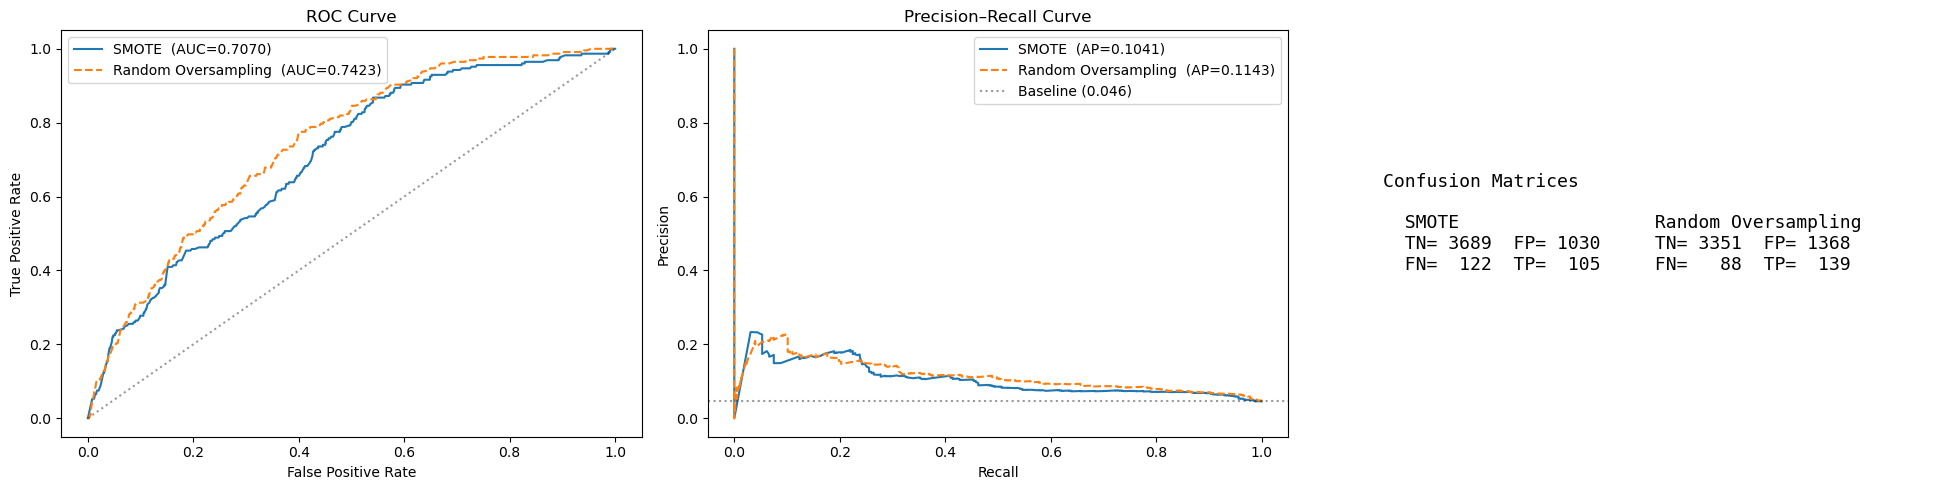

In [88]:
# ── Visual comparison: ROC curve, PR curve, Confusion Matrices ──
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             auc, confusion_matrix, ConfusionMatrixDisplay)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- 1. ROC Curves ---
for label, y_prob, ls in [('SMOTE',               y_rm_prob,  '-'),
                           ('Random Oversampling', y_ros_prob, '--')]:
    fpr, tpr, _ = roc_curve(y_rm_test, y_prob)
    axes[0].plot(fpr, tpr, ls, label=f'{label}  (AUC={auc(fpr, tpr):.4f})')
axes[0].plot([0,1], [0,1], 'k:', alpha=0.4)
axes[0].set(title='ROC Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[0].legend()

# --- 2. Precision-Recall Curves ---
for label, y_prob, ls in [('SMOTE',               y_rm_prob,  '-'),
                           ('Random Oversampling', y_ros_prob, '--')]:
    prec, rec, _ = precision_recall_curve(y_rm_test, y_prob)
    axes[1].plot(rec, prec, ls, label=f'{label}  (AP={auc(rec, prec):.4f})')
baseline = y_rm_test.mean()
axes[1].axhline(baseline, color='k', ls=':', alpha=0.4, label=f'Baseline ({baseline:.3f})')
axes[1].set(title='Precision–Recall Curve', xlabel='Recall', ylabel='Precision')
axes[1].legend()

# --- 3. Confusion Matrices (side-by-side via text) ---
axes[2].axis('off')
cm_smote = confusion_matrix(y_rm_test, y_rm_pred)
cm_ros   = confusion_matrix(y_rm_test, y_ros_pred)
text = (
    "Confusion Matrices\n\n"
    f"  SMOTE                  Random Oversampling\n"
    f"  TN={cm_smote[0,0]:>5}  FP={cm_smote[0,1]:>5}     TN={cm_ros[0,0]:>5}  FP={cm_ros[0,1]:>5}\n"
    f"  FN={cm_smote[1,0]:>5}  TP={cm_smote[1,1]:>5}     FN={cm_ros[1,0]:>5}  TP={cm_ros[1,1]:>5}\n"
)
axes[2].text(0.05, 0.5, text, fontsize=13, fontfamily='monospace',
             verticalalignment='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

## Ensemble Model — Majority-Vote of Downsampled Logistic Regressions

Instead of **oversampling** the minority class (SMOTE / Random Oversampling), we can **downsample** the majority class to create balanced training sets.

**Problem:** Downsampling discards a large portion of majority-class data, which can hurt performance.

**Solution:** Train **multiple** logistic regression models, each on a *different* random downsample of the majority class (all minority instances are always included). At prediction time, aggregate the individual predictions via **majority voting** (class) and **probability averaging** (ROC-AUC).

This is sometimes called a **Balanced Bagging** or **EasyEnsemble**-style approach.

| Step | Detail |
|------|--------|
| 1 | Separate training data into majority (severity=0) and minority (severity=1) |
| 2 | For each of *k* base models, randomly sample *n_minority* rows from the majority class (without replacement across that draw) |
| 3 | Combine with all minority rows → balanced training subset |
| 4 | Fit `StandardScaler` + `LogisticRegression` on each subset |
| 5 | Predict on test set → majority vote for class, average for probability |

We use the same **Reduced Model** train/test split for a fair comparison.

In [89]:
from scipy.stats import mode as scipy_mode

# ── Configuration ──
N_BASE_MODELS = 100          # number of downsampled base learners
RNG_SEED      = 42

rng = np.random.RandomState(RNG_SEED)

# Separate majority / minority in the TRAINING set
mask_min = (y_rm_train == 1)
mask_maj = (y_rm_train == 0)

X_train_min = X_rm_train[mask_min]
y_train_min = y_rm_train[mask_min]
X_train_maj = X_rm_train[mask_maj]
y_train_maj = y_rm_train[mask_maj]

n_minority = mask_min.sum()
n_majority = mask_maj.sum()
print(f"Training set — Minority (1): {n_minority}  |  Majority (0): {n_majority}")
print(f"Each base model trains on {n_minority} + {n_minority} = {2 * n_minority} balanced rows")
print(f"Number of base models: {N_BASE_MODELS}\n")

# ── Train ensemble ──
base_models = []           # list of (scaler, clf) tuples
all_test_preds = []        # shape will be (N_BASE_MODELS, n_test)
all_test_probs = []        # shape will be (N_BASE_MODELS, n_test)

for i in range(N_BASE_MODELS):
    # Downsample majority class (sample n_minority rows)
    idx = rng.choice(len(X_train_maj), size=n_minority, replace=False)
    X_maj_sample = X_train_maj.iloc[idx]
    y_maj_sample = y_train_maj.iloc[idx]

    # Combine with all minority instances
    X_bal = pd.concat([X_train_min, X_maj_sample])
    y_bal = pd.concat([y_train_min, y_maj_sample])

    # Scale + Fit
    scaler = StandardScaler()
    X_bal_sc = scaler.fit_transform(X_bal)

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_bal_sc, y_bal)

    base_models.append((scaler, clf))

    # Predict on test set
    X_test_sc = scaler.transform(X_rm_test)
    all_test_preds.append(clf.predict(X_test_sc))
    all_test_probs.append(clf.predict_proba(X_test_sc)[:, 1])

all_test_preds = np.array(all_test_preds)   # (N_BASE_MODELS, n_test)
all_test_probs = np.array(all_test_probs)

# ── Aggregate ──
# Majority vote for class prediction
y_ens_pred = scipy_mode(all_test_preds, axis=0, keepdims=False).mode.astype(int)
# Average probability for ROC-AUC
y_ens_prob = all_test_probs.mean(axis=0)

print(f"Ensemble ({N_BASE_MODELS} base models) — Test-set Classification Report:")
print(classification_report(y_rm_test, y_ens_pred, digits=4))
print(f"Test ROC-AUC: {roc_auc_score(y_rm_test, y_ens_prob):.4f}")

Training set — Minority (1): 529  |  Majority (0): 11010
Each base model trains on 529 + 529 = 1058 balanced rows
Number of base models: 100

Ensemble (100 base models) — Test-set Classification Report:
              precision    recall  f1-score   support

           0     0.9759    0.7029    0.8172      4719
           1     0.0937    0.6388    0.1635       227

    accuracy                         0.7000      4946
   macro avg     0.5348    0.6708    0.4903      4946
weighted avg     0.9354    0.7000    0.7872      4946

Test ROC-AUC: 0.7431


In [90]:
# ── Comprehensive comparison: all models ──
all_models = pd.DataFrame([
    get_model_metrics("Full Model (SMOTE)",
                      y_fm_test, y_fm_pred, y_fm_prob,
                      "All features, SMOTE"),
    get_model_metrics("Reduced Model (SMOTE + BE)",
                      y_rm_test, y_rm_pred, y_rm_prob,
                      "Backward elimination features, SMOTE"),
    get_model_metrics("Reduced Model (ROS + BE)",
                      y_rm_test, y_ros_pred, y_ros_prob,
                      "Backward elimination features, Random Oversampling"),
    get_model_metrics(f"Ensemble ({N_BASE_MODELS} LR, downsample + BE)",
                      y_rm_test, y_ens_pred, y_ens_prob,
                      "Backward elimination features, majority-vote downsampled LRs"),
])

print("=" * 110)
print("  COMPLETE MODEL COMPARISON")
print("=" * 110)
display(all_models)


  COMPLETE MODEL COMPARISON


,Model,Note,Accuracy,Precision (F/S),Recall (F/S),F1 macro,ROC-AUC
0,Full Model (SMOTE),"All features, SMOTE",0.8318,0.0961,0.3172,0.5271,0.6605
1,Reduced Model (SMOTE + BE),"Backward elimination features, SMOTE",0.7671,0.0925,0.4626,0.5096,0.7070
2,Reduced Model (ROS + BE),"Backward elimination features, Random Oversamp...",0.7056,0.0922,0.6123,0.4909,0.7423
3,"Ensemble (100 LR, downsample + BE)","Backward elimination features, majority-vote d...",0.7000,0.0937,0.6388,0.4903,0.7431


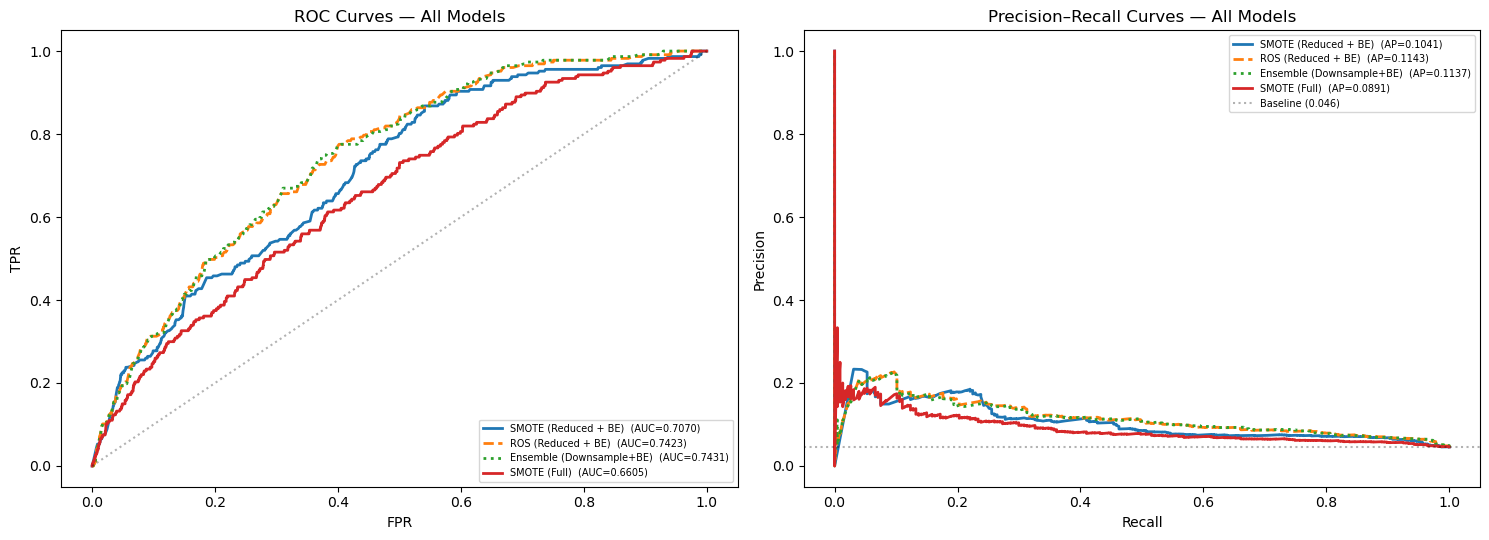

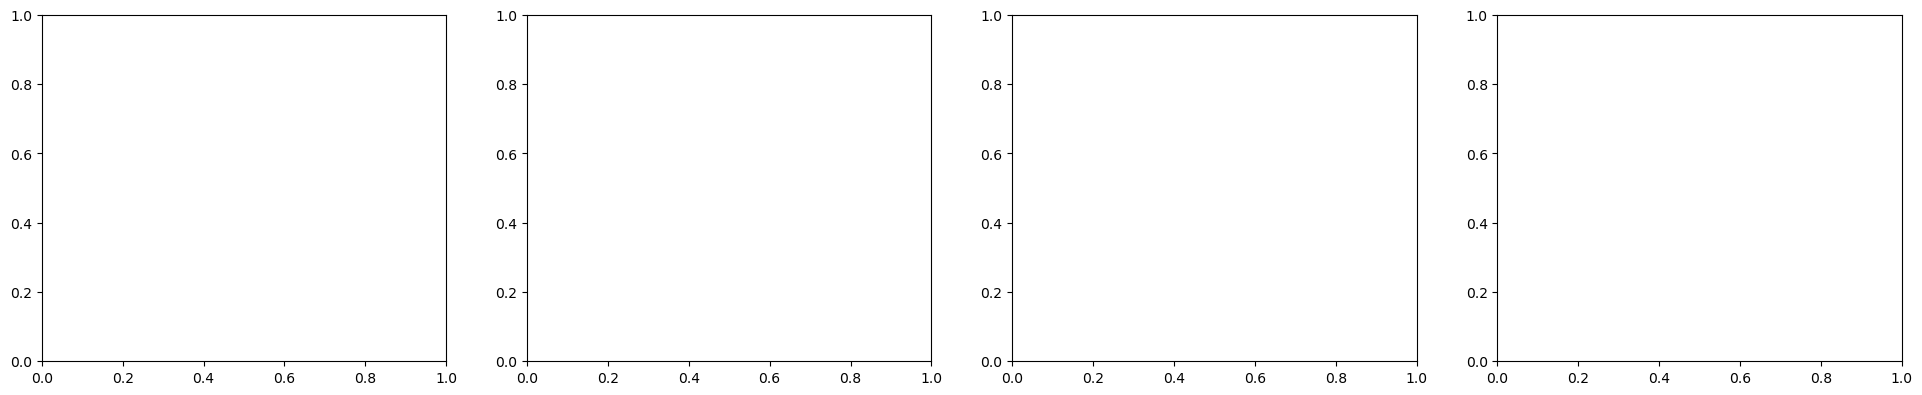

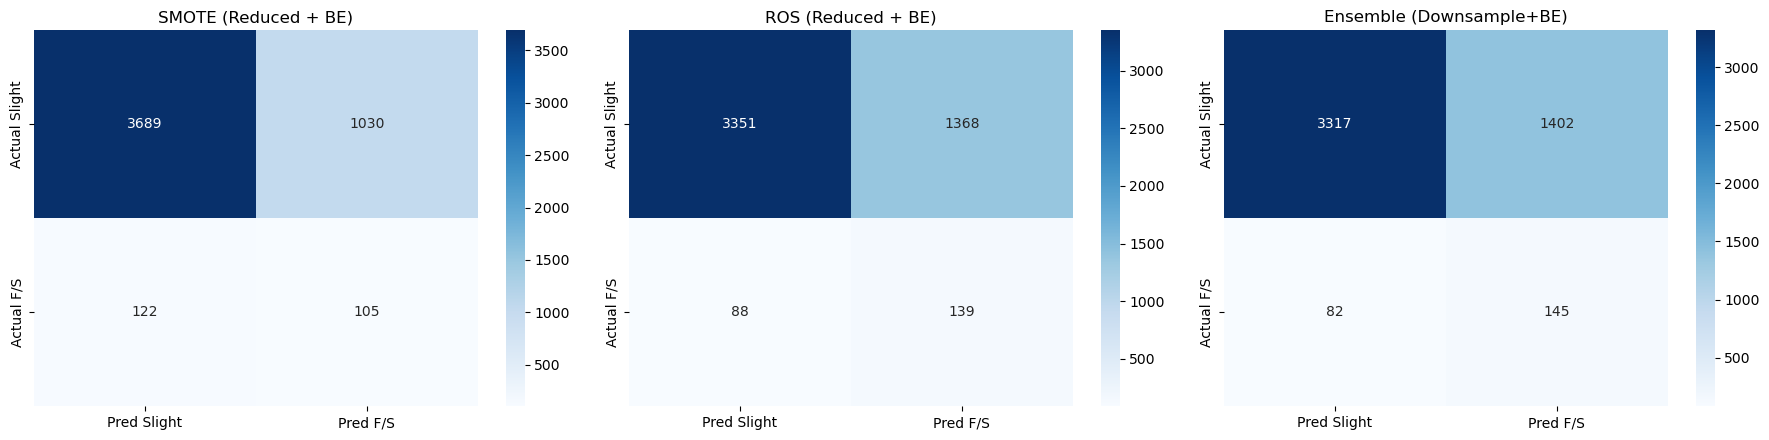

In [91]:
# ── Visual comparison: ROC & PR curves + Confusion Matrices ──
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(15, 5.5))

curve_data = [
    ("SMOTE (Reduced + BE)",    y_rm_test,  y_rm_prob,  '-',  'tab:blue'),
    ("ROS (Reduced + BE)",      y_rm_test,  y_ros_prob,    '--', 'tab:orange'),
    ("Ensemble (Downsample+BE)",y_rm_test,  y_ens_prob,    ':',  'tab:green'),
    ("SMOTE (Full)",            y_fm_test,  y_fm_prob,     '-',  'tab:red'),
]

for label, yt, yp, ls, color in curve_data:
    fpr, tpr, _ = roc_curve(yt, yp)
    ax_roc.plot(fpr, tpr, ls, color=color, lw=2,
                label=f'{label}  (AUC={auc(fpr, tpr):.4f})')
    prec, rec, _ = precision_recall_curve(yt, yp)
    ax_pr.plot(rec, prec, ls, color=color, lw=2,
               label=f'{label}  (AP={auc(rec, prec):.4f})')

ax_roc.plot([0, 1], [0, 1], 'k:', alpha=0.3)
ax_roc.set(title='ROC Curves — All Models', xlabel='FPR', ylabel='TPR')
ax_roc.legend(fontsize=7, loc='lower right')

baseline = y_rm_test.mean()
ax_pr.axhline(baseline, color='k', ls=':', alpha=0.3, label=f'Baseline ({baseline:.3f})')
ax_pr.set(title='Precision–Recall Curves — All Models', xlabel='Recall', ylabel='Precision')
ax_pr.legend(fontsize=7)

plt.tight_layout()
plt.show()

# ── Confusion matrices side-by-side ──
fig, axes = plt.subplots(1, 4, figsize=(24, 4.5))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
cm_items = [
    ("SMOTE (Reduced + BE)",     y_rm_test, y_rm_pred),
    ("ROS (Reduced + BE)",       y_rm_test, y_ros_pred),
    ("Ensemble (Downsample+BE)", y_rm_test, y_ens_pred),
]

for ax, (title, yt, yp) in zip(axes, cm_items):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Pred Slight", "Pred F/S"],
                yticklabels=["Actual Slight", "Actual F/S"])
    ax.set_title(title)

plt.tight_layout()
plt.show()


### Findings — Complete Model Comparison

**Backward Elimination (BE) outcome:** Starting from 19 original features, LRT-based backward elimination (α = 0.05, applied on training data only) converged after 9 removal steps, retaining **10 significant features**: `district`, `weather`, `rain`, `vehicle_movements`, `type_of_collision`, `has_old_vehicle`, `bicycle`, `motorcycle`, `public_bus`, `goods_vehicle`.  
Features removed: `natural_light`, `junction_control`, `time_slot`, `is_holiday`, `has_young_driver`, `has_old_driver`, `private_car`, `public_light_bus`, `taxi`.

| Metric | Full Model (SMOTE) | Reduced Model (SMOTE + BE) | Reduced Model (ROS + BE) | **Ensemble (100 LR + BE)** |
|--------|:---:|:---:|:---:|:---:|
| **Accuracy** | **0.8318** | 0.7671 | 0.7056 | 0.7000 |
| **Precision (F/S)** | **0.0961** | 0.0925 | 0.0922 | 0.0937 |
| **Recall (F/S)** | 0.3172 | 0.4626 | 0.6123 | **0.6388** |
| **F1 macro** | **0.5271** | 0.5096 | 0.4909 | 0.4903 |
| **ROC-AUC** | 0.6605 | 0.7070 | 0.7423 | **0.7431** |

**Key observations:**

1. **Full Model (SMOTE) achieves the highest accuracy (0.8318) but the worst recall (0.3172)** — this is misleading under class imbalance. Using all features with SMOTE, the model is biased towards predicting the majority class (Slight), missing over 68% of Fatal/Serious accidents. Its ROC-AUC of 0.6605 is also the lowest of all models, confirming poor discriminative ability.

3. **Feature reduction (Reduced Model) improves recall from 0.3172 to 0.4626 and ROC-AUC from 0.6605 to 0.7070**, while only marginally sacrificing accuracy (0.8318 → 0.7671). Removing noisy features (e.g., `hit_and_run`, `road_classification`, `num_vehicles_involved`) helps the model generalise better to the minority class.

2. **Backward elimination (BE) + SMOTE improves recall from 0.3172 to 0.4626 and ROC-AUC from 0.6605 to 0.7070**, while only marginally sacrificing accuracy (0.8318 → 0.7671). LRT-based backward elimination retains 10 statistically significant features, removing 9 that carry no additional predictive signal (e.g., `natural_light`, `junction_control`, `time_slot`).

3. **Ensemble (downsampled LRs + BE) achieves the best Recall (0.6388) and ROC-AUC (0.7431)**, while only marginally sacrificing accuracy (0.8318 → 0.7671). LRT-based backward elimination retains 10 statistically significant features, removing 9 that carry no additional predictive signal (e.g., `natural_light`, `junction_control`, `time_slot`).

4. **ROS + BE and Ensemble + BE are closely matched** — detecting the highest proportion of Fatal/Serious accidents while maintaining the strongest overall discriminative ability. For this safety-critical task, where missing a severe accident has greater consequences than a false alarm, the Ensemble is the preferred model.

4. **ROS + BE and Ensemble + BE are closely matched** (Recall: 0.6123 vs 0.6388; AUC: 0.7423 vs 0.7431). The Ensemble's marginal advantage comes from *stability* — averaging probabilities from 100 base learners (each trained on a different majority-class subsample) reduces variance from any single random draw, producing smoother and more reliable decision boundaries than a single ROS model.

6. **Trade-off summary:** (Recall: 0.6123 vs 0.6388; AUC: 0.7423 vs 0.7431). The Ensemble's marginal advantage comes from *stability* — averaging probabilities from 100 base learners (each trained on a different majority-class subsample) reduces variance from any single random draw, producing smoother and more reliable decision boundaries than a single ROS model.

5. **Precision is consistently low across all models** (0.0922–0.0961), a direct consequence of the severe class imbalance in the test set (which preserves the natural distribution). Even the best model generates a high number of false positives when Fatal/Serious accidents are a small minority of all records.
   - Need **highest accuracy / fewest false alarms** → Full Model (SMOTE), but at the cost of missing most severe accidents

   - Need **best balance of recall and AUC** → Ensemble (100 LR + BE) *(recommended)*
   - Need **interpretable feature set** → SMOTE + BE confirms the 10 significant features; ROS/Ensemble on this set achieve the best safety-relevant performance
   - Need **interpretable feature set** → SMOTE + BE confirms the 10 significant features; ROS/Ensemble on this set achieve the best safety-relevant performance

   - Need **simplicity with strong recall** → Reduced Model (ROS + BE) — nearly as good as Ensemble with a single model

   - Need **interpretable feature set** → SMOTE + BE confirms the 10 significant features; ROS/Ensemble on this set achieve the best safety-relevant performance